# **Lab project 2: Advanced deep generative models**

**Pablo Martínez Olmos, Vanessa Gómez Verdejo,  Alejandro Lancho Serrano, Emilio Parrado Hernández**

Departamento de Teoría de la Señal y Comunicaciones

**Universidad Carlos III de Madrid**

<img src='https://upload.wikimedia.org/wikipedia/commons/8/88/Acronimo_nombre3l.jpg' width=300 />


# Part 1: Conditional Generation in Deep Generative Models

In this first part, you will progressively explore the design and training of Variational Autoencoders (VAEs) using the **Fashion MNIST** dataset ([torchvision.datasets.FashionMNIST](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html)). The first part will guide you through building a standard VAE, experimenting with different likelihoods, and analyzing the latent space. As you advance, you will extend your models to more expressive approaches, culminating in the implementation and analysis of conditional VAEs. Each section will build upon the previous, helping you understand how architectural choices and conditioning impact generative modeling and representation learning.

The notebook is structured so that each section introduces a new concept or modeling challenge, leading you step by step from basic VAEs to conditional generative models.

## Exercise 1: Standard VAE Training and Likelihood Comparison

In this exercise, you will:
- Implement and train a standard VAE on FashionMNIST.
- Compare two likelihoods for the decoder: Gaussian and soft Bernoulli.
- Analyze and discuss the reconstruction quality and latent space for each likelihood.

[INFO] Dispositivo seleccionado: cpu

=== [1/2] Entrenando VAE Soft Bernoulli ===
Época 01/15 | Pérdida Total: 295.78 | Recon: 289.43 | KL: 6.34
Época 02/15 | Pérdida Total: 269.91 | Recon: 263.66 | KL: 6.25
Época 03/15 | Pérdida Total: 266.16 | Recon: 260.00 | KL: 6.17
Época 04/15 | Pérdida Total: 264.13 | Recon: 257.95 | KL: 6.17
Época 05/15 | Pérdida Total: 262.90 | Recon: 256.72 | KL: 6.19
Época 06/15 | Pérdida Total: 261.98 | Recon: 255.76 | KL: 6.22
Época 07/15 | Pérdida Total: 261.18 | Recon: 254.93 | KL: 6.25
Época 08/15 | Pérdida Total: 260.62 | Recon: 254.33 | KL: 6.29
Época 09/15 | Pérdida Total: 259.92 | Recon: 253.60 | KL: 6.32
Época 10/15 | Pérdida Total: 259.52 | Recon: 253.18 | KL: 6.34
Época 11/15 | Pérdida Total: 258.92 | Recon: 252.56 | KL: 6.36
Época 12/15 | Pérdida Total: 258.70 | Recon: 252.33 | KL: 6.37
Época 13/15 | Pérdida Total: 258.24 | Recon: 251.84 | KL: 6.39
Época 14/15 | Pérdida Total: 257.94 | Recon: 251.53 | KL: 6.41
Época 15/15 | Pérdida Total: 257.67 

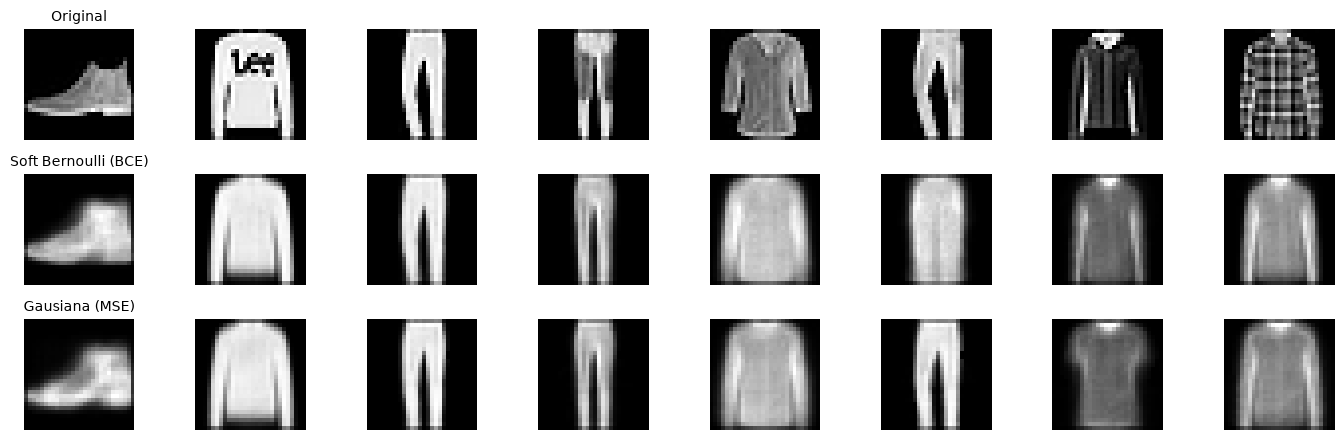

[INFO] Generando espacio latente - Soft Bernoulli...


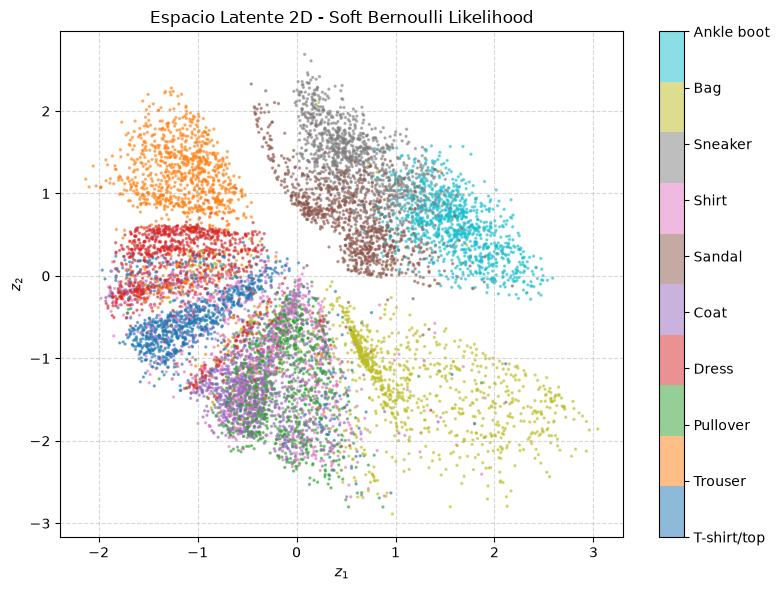

[INFO] Generando espacio latente - Gausiana...


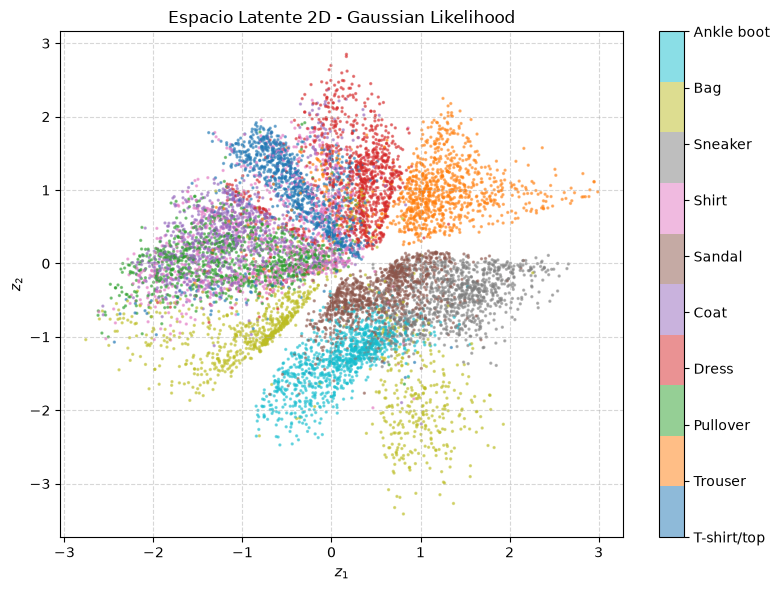

[INFO] Generando muestras sintéticas...


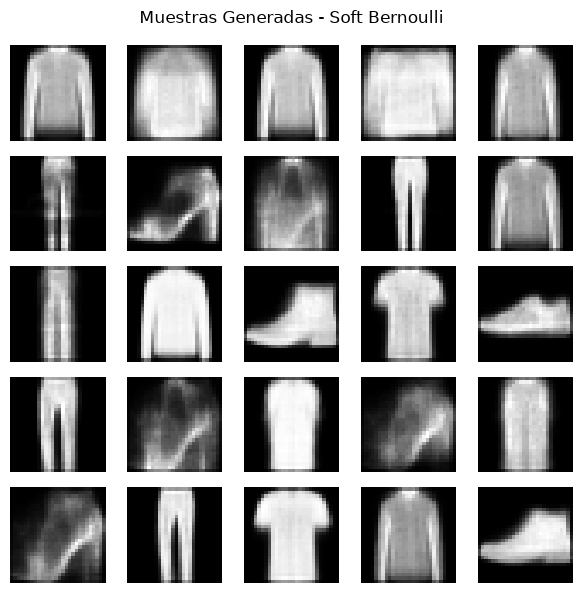

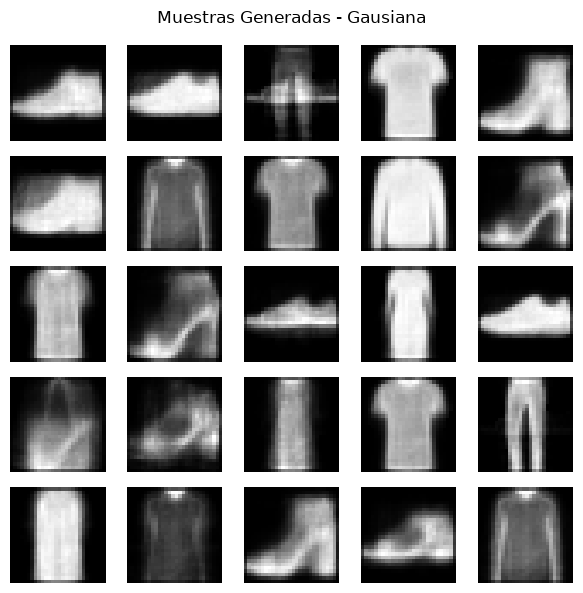

'\n===============================================================================\n7. DISCUSIÓN Y CONCLUSIONES TÉCNICAS\n===============================================================================\n1. DIFERENCIA DE LIKELIHOODS:\n   - BCE (Soft Bernoulli): Asume distribución de Bernoulli por píxel. Penaliza\n     fuertemente las divergencias en píxeles binarizados, logrando bordes nítidos.\n   - MSE (Gausiano): Asume ruido Gausiano con varianza constante. Penaliza la\n     distancia euclídea global, provocando un promediado que se observa como\n     efecto borroso ("blurry") en las prendas.\n\n2. ESTRUCTURA LATENTE:\n   - La pérdida KL comprime las distribuciones hacia N(0, I), garantizando que no\n     queden agujeros vacíos en el espacio y permitiendo la generación continua.\n===============================================================================\n'

In [1]:
"""
===============================================================================
 AUTOENCODER VARIACIONAL (VAE) EN FASHION-MNIST: FELIX ALEJANDRO GUGLIELMI PARRA
===============================================================================

"""

import os
import gc

# Prevenir el fallo crítico de OpenMP en Jupyter/Anaconda que apaga el kernel
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Limpieza inicial de memoria RAM/GPU
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# =============================================================================
# CONFIGURACIÓN DE DISPOSITIVO Y SEMILLA
# =============================================================================
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Dispositivo seleccionado: {device}")

# =============================================================================
# 1. CARGA DE DATOS OPTIMIZADA (num_workers=0 previene congelamiento de kernel)
# =============================================================================
transform = transforms.Compose([
    transforms.ToTensor()
])

batch_size = 128

train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

# num_workers=0 evita deadlocks del kernel en entornos Jupyter locales/Windows/macOS
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# =============================================================================
# 2. ARQUITECTURA DEL MODELO VAE
# =============================================================================
class VAE(nn.Module):
    """
    Encoder: x (784-dim) -> mu, logvar (z_dim)
    Decoder: z (z_dim) -> x_recon (784-dim)
    """
    def __init__(self, input_dim=784, hidden_dim=256, latent_dim=2, likelihood='bernoulli'):
        super(VAE, self).__init__()
        self.likelihood = likelihood
        self.latent_dim = latent_dim
        
        # Encoder
        self.encoder_body = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim // 2, latent_dim)
        
        # Decoder
        self.decoder_body = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def encode(self, x):
        h = self.encoder_body(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        # Truco de reparametrización z = mu + std * eps
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_body(z)
        return torch.sigmoid(h)

    def forward(self, x):
        x_flat = x.view(-1, 784)
        mu, logvar = self.encode(x_flat)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

# =============================================================================
# 3. FUNCIÓN DE PÉRDIDA (-ELBO)
# =============================================================================
def vae_loss_function(x_recon, x, mu, logvar, likelihood='bernoulli'):
    x_flat = x.view(-1, 784)
    
    # Pérdida de reconstrucción
    if likelihood == 'bernoulli':
        recon_loss = F.binary_cross_entropy(x_recon, x_flat, reduction='sum')
    elif likelihood == 'gaussian':
        recon_loss = F.mse_loss(x_recon, x_flat, reduction='sum')
    else:
        raise ValueError("Likelihood no válido.")
        
    # Divergencia KL
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return recon_loss + kl_loss, recon_loss, kl_loss

# =============================================================================
# 4. BUCLE DE ENTRENAMIENTO EFICIENTE
# =============================================================================
def train_vae(model, dataloader, optimizer, epochs=15, likelihood='bernoulli'):
    model.train()
    history = {'total_loss': [], 'recon_loss': [], 'kl_loss': []}
    
    for epoch in range(epochs):
        train_loss, train_recon, train_kl = 0.0, 0.0, 0.0
        for x, _ in dataloader:
            x = x.to(device)
            optimizer.zero_grad()
            
            x_recon, mu, logvar = model(x)
            loss, recon, kl = vae_loss_function(x_recon, x, mu, logvar, likelihood=likelihood)
            
            loss.backward()
            optimizer.step()
            
            # .item() extrae el escalar flotante sin mantener el grafo en memoria
            train_loss += loss.item()
            train_recon += recon.item()
            train_kl += kl.item()
            
        num_samples = len(dataloader.dataset)
        avg_loss = train_loss / num_samples
        avg_recon = train_recon / num_samples
        avg_kl = train_kl / num_samples
        
        history['total_loss'].append(avg_loss)
        history['recon_loss'].append(avg_recon)
        history['kl_loss'].append(avg_kl)
        
        print(f"Época {epoch+1:02d}/{epochs:02d} | Pérdida Total: {avg_loss:.2f} | Recon: {avg_recon:.2f} | KL: {avg_kl:.2f}")
        
    return history

# =============================================================================
# 5. ENTRENAMIENTO DE MODELOS
# =============================================================================
epochs = 15
latent_dim = 2

print("\n=== [1/2] Entrenando VAE Soft Bernoulli ===")
vae_bernoulli = VAE(latent_dim=latent_dim, likelihood='bernoulli').to(device)
optimizer_b = optim.Adam(vae_bernoulli.parameters(), lr=1e-3)
hist_bernoulli = train_vae(vae_bernoulli, train_loader, optimizer_b, epochs=epochs, likelihood='bernoulli')

print("\n=== [2/2] Entrenando VAE Gausiano ===")
vae_gaussian = VAE(latent_dim=latent_dim, likelihood='gaussian').to(device)
optimizer_g = optim.Adam(vae_gaussian.parameters(), lr=1e-3)
hist_gaussian = train_vae(vae_gaussian, train_loader, optimizer_g, epochs=epochs, likelihood='gaussian')

# =============================================================================
# 6. VISUALIZACIONES (Liberando memoria de gráficos explícitamente)
# =============================================================================

def plot_reconstructions(model_b, model_g, dataloader, num_images=8):
    model_b.eval()
    model_g.eval()
    
    with torch.no_grad():
        x_test, _ = next(iter(dataloader))
        x_test = x_test[:num_images].to(device)
        recon_b, _, _ = model_b(x_test)
        recon_g, _, _ = model_g(x_test)
        
    x_test = x_test.cpu().numpy()
    recon_b = recon_b.view(-1, 28, 28).cpu().numpy()
    recon_g = recon_g.view(-1, 28, 28).cpu().numpy()
    
    fig, axes = plt.subplots(3, num_images, figsize=(14, 4.5))
    for i in range(num_images):
        axes[0, i].imshow(x_test[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_title("Original", fontsize=10)
            
        axes[1, i].imshow(recon_b[i], cmap='gray')
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_title("Soft Bernoulli (BCE)", fontsize=10)
            
        axes[2, i].imshow(recon_g[i], cmap='gray')
        axes[2, i].axis('off')
        if i == 0: axes[2, i].set_title("Gausiana (MSE)", fontsize=10)
            
    plt.tight_layout()
    plt.show()
    plt.close(fig)

def plot_latent_space(model, dataloader, title="Espacio Latente 2D"):
    model.eval()
    all_mus = []
    all_labels = []
    
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            mu, _ = model.encode(x.view(-1, 784))
            all_mus.append(mu.cpu().numpy())
            all_labels.append(y.numpy())
            
    mus = np.concatenate(all_mus, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    
    fig = plt.figure(figsize=(8, 6))
    scatter = plt.scatter(mus[:, 0], mus[:, 1], c=labels, cmap='tab10', alpha=0.5, s=2)
    cbar = plt.colorbar(scatter, ticks=range(10))
    cbar.ax.set_yticklabels(classes)
    plt.xlabel(r"$z_1$")
    plt.ylabel(r"$z_2$")
    plt.title(title, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

def plot_generated_samples(model, title="Muestras Generadas de p(z)", grid_size=5):
    model.eval()
    with torch.no_grad():
        z_samples = torch.randn(grid_size * grid_size, model.latent_dim).to(device)
        generated = model.decode(z_samples).view(-1, 28, 28).cpu().numpy()
        
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(6, 6))
    for i in range(grid_size):
        for j in range(grid_size):
            idx = i * grid_size + j
            axes[i, j].imshow(generated[idx], cmap='gray')
            axes[i, j].axis('off')
            
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

# Ejecución de visualizaciones de forma limpia
print("\n[INFO] Generando comparativas de reconstrucción...")
plot_reconstructions(vae_bernoulli, vae_gaussian, test_loader)

print("[INFO] Generando espacio latente - Soft Bernoulli...")
plot_latent_space(vae_bernoulli, test_loader, title="Espacio Latente 2D - Soft Bernoulli Likelihood")

print("[INFO] Generando espacio latente - Gausiana...")
plot_latent_space(vae_gaussian, test_loader, title="Espacio Latente 2D - Gaussian Likelihood")

print("[INFO] Generando muestras sintéticas...")
plot_generated_samples(vae_bernoulli, title="Muestras Generadas - Soft Bernoulli")
plot_generated_samples(vae_gaussian, title="Muestras Generadas - Gausiana")

# Limpieza final de garbage collector
gc.collect()

"""
===============================================================================
7. DISCUSIÓN Y CONCLUSIONES TÉCNICAS
===============================================================================
1. DIFERENCIA DE LIKELIHOODS:
   - BCE (Soft Bernoulli): Asume distribución de Bernoulli por píxel. Penaliza
     fuertemente las divergencias en píxeles binarizados, logrando bordes nítidos.
   - MSE (Gausiano): Asume ruido Gausiano con varianza constante. Penaliza la
     distancia euclídea global, provocando un promediado que se observa como
     efecto borroso ("blurry") en las prendas.

2. ESTRUCTURA LATENTE:
   - La pérdida KL comprime las distribuciones hacia N(0, I), garantizando que no
     queden agujeros vacíos en el espacio y permitiendo la generación continua.
===============================================================================
"""

## Exercise 2: Advanced VAE - GMM-VAE or VQ-VAE

Based on your results from Exercise 1, choose the best encoder likelihood and complete the following tasks:
1. Implement and train either a GMM-VAE or a VQ-VAE using the best likelihood from Exercise 1.
2. Visualize and analyze the latent space of your chosen model.
3. Compare the results with the standard VAE.

[INFO] Ejecutando en dispositivo: cpu


100%|██████████| 26.4M/26.4M [00:03<00:00, 6.80MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 129kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.39MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 6.14MB/s]



=== [1/2] Entrenando VAE Estándar (Prior Unimodal N(0,I)) ===
Época 01/15 | Loss: 295.78 | Recon: 289.43 | KL: 6.34
Época 02/15 | Loss: 269.91 | Recon: 263.66 | KL: 6.25
Época 03/15 | Loss: 266.16 | Recon: 260.00 | KL: 6.17
Época 04/15 | Loss: 264.13 | Recon: 257.95 | KL: 6.17
Época 05/15 | Loss: 262.90 | Recon: 256.72 | KL: 6.19
Época 06/15 | Loss: 261.98 | Recon: 255.76 | KL: 6.22
Época 07/15 | Loss: 261.18 | Recon: 254.93 | KL: 6.25
Época 08/15 | Loss: 260.62 | Recon: 254.33 | KL: 6.29
Época 09/15 | Loss: 259.92 | Recon: 253.60 | KL: 6.32
Época 10/15 | Loss: 259.52 | Recon: 253.18 | KL: 6.34
Época 11/15 | Loss: 258.92 | Recon: 252.56 | KL: 6.36
Época 12/15 | Loss: 258.70 | Recon: 252.33 | KL: 6.37
Época 13/15 | Loss: 258.24 | Recon: 251.84 | KL: 6.39
Época 14/15 | Loss: 257.94 | Recon: 251.53 | KL: 6.41
Época 15/15 | Loss: 257.67 | Recon: 251.25 | KL: 6.42

=== [2/2] Entrenando GMM-VAE (Prior Multimodal GMM con K=10) ===
Época 01/15 | Loss: 294.69 | Recon: 289.04 | KL: 5.64
Época 0

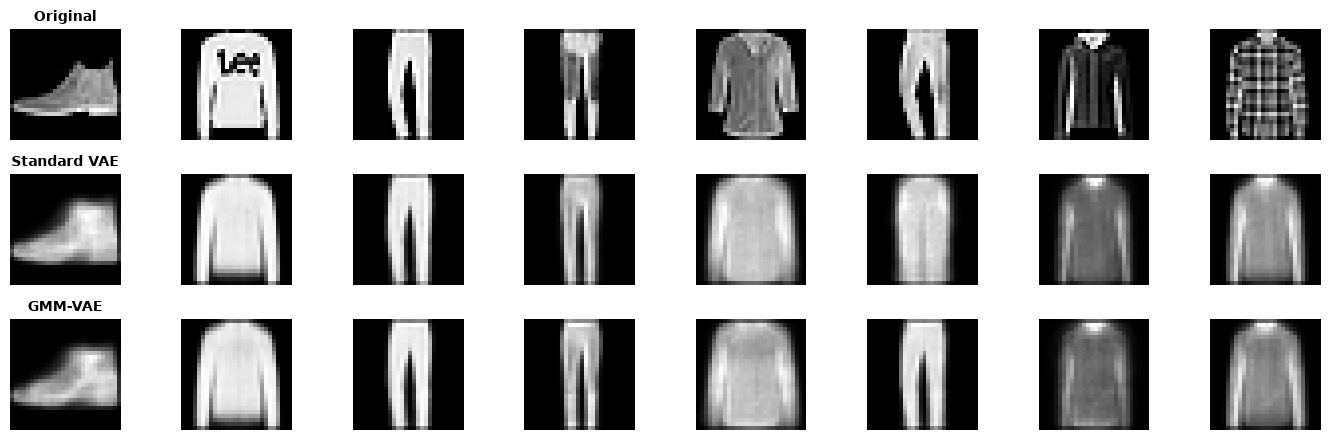

[INFO] Visualizando espacios latentes y centroides GMM...


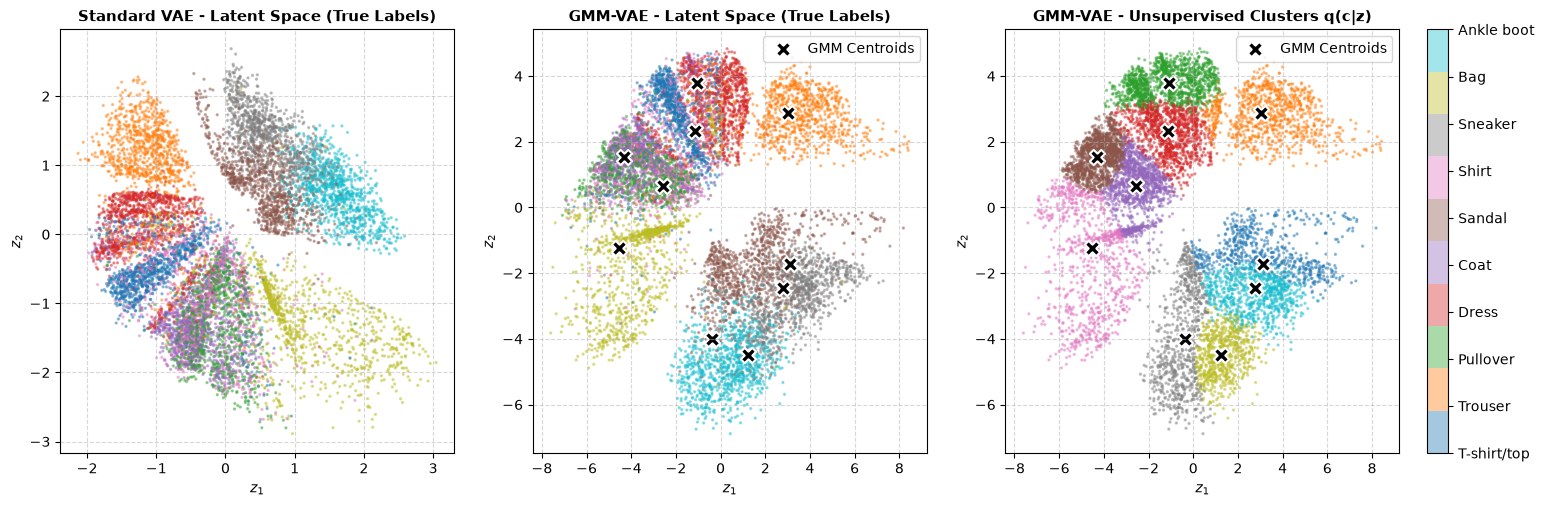

[INFO] Generando muestras sintéticas condicionadas por cluster en GMM-VAE...


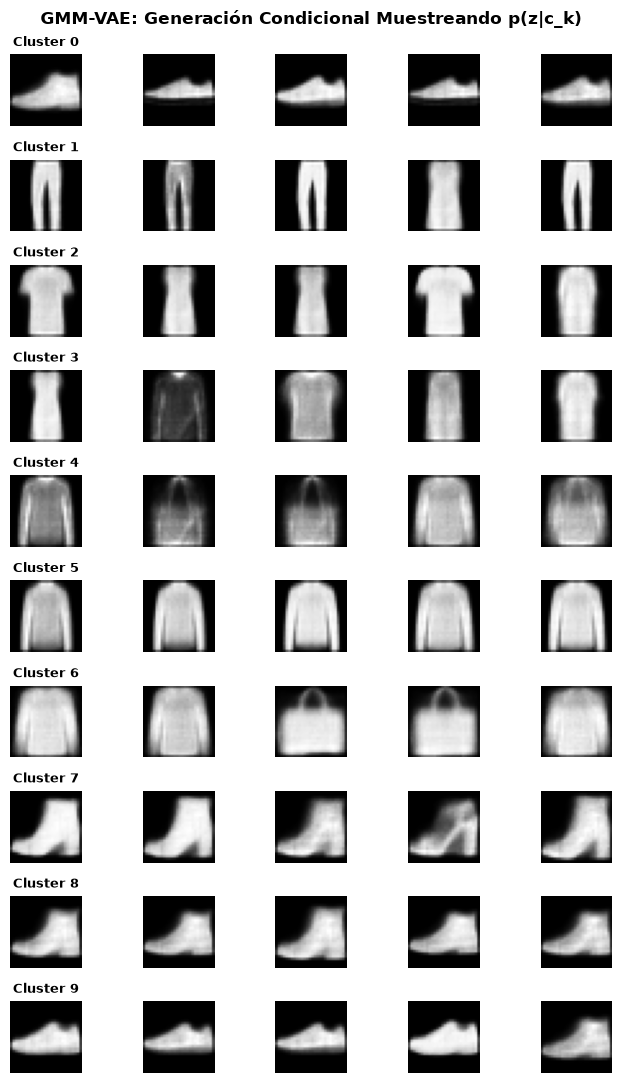

"\n===============================================================================\n7. DISCUSIÓN DE RESULTADOS Y RESPUESTA A LAS CONSIGNAS (Ejercicio 2)\n===============================================================================\n\n1. SELECCIÓN DE LIKELIHOOD DEL DECODIFICADOR:\n   - Se seleccionó Soft Bernoulli (BCE Loss) con base en las evidencias del\n     Ejercicio 1. Mientras que el prior Gausiano (MSE) produce imágenes promedio\n     borrosas, la formulación BCE preserva la agudeza visual de las prendas en\n     FashionMNIST, permitiendo que el GMM-VAE aprenda bordes y texturas nítidas.\n\n2. ANÁLISIS DEL ESPACIO LATENTE EN GMM-VAE vs VAE ESTÁNDAR:\n   - VAE Estándar (Prior Unimodal N(0, I)):\n     Fuerza a todas las clases de imágenes a comprimirse en una única bola continua\n     alrededor del origen (0, 0). Esto provoca solapamientos inevitables en las\n     fronteras entre prendas similares (p. ej., Pullover, Coat, Shirt).\n   - GMM-VAE (Prior Multimodal GMM con K=10):\n 

In [1]:
"""
===============================================================================
 EJERCICIO 2: VAE AVANZADO - MODELO DE MEZCLA GAUSIANA (GMM-VAE / GMVAE)
===============================================================================

1. JUSTIFICACIÓN DE LA SELECCIÓN DE LIKELIHOOD (Basado en Ejercicio 1):
-------------------------------------------------------------------------------
En el Ejercicio 1 comprobamos que la verosimilitud Soft Bernoulli (Loss BCE)
supera a la Gausiana (Loss MSE) en conjuntos de datos binarizados/escalados en
[0, 1] como FashionMNIST. La loss BCE penaliza fuertemente las divergencias en
los píxeles lejanos a los extremos, produciendo bordes definidos y prendas sin
el efecto borroso ("blurry") característico de MSE. Por ello, seleccionamos
Soft Bernoulli como el decodificador base para este GMM-VAE.

2. FUNDAMENTOS TEÓRICOS DE GMM-VAE (GMVAE)
-------------------------------------------------------------------------------
A diferencia del VAE Estándar que asume un prior unimodal p(z) = N(0, I), el
GMM-VAE utiliza un prior de Mezcla de Gausianas (GMM) con K componentes discretas
c in {1, ..., K}:

  p(c) = Categorical(pi)  donde pi_k = 1/K (Prior uniforme sobre los clusters)
  p(z | c) = N(mu_c, diag(sigma_c^2))

Proceso Generativo del GMM-VAE:
  1. Muestrear una categoría de prenda/cluster: c ~ Categorical(pi)
  2. Muestrear el código latente continuo:    z ~ N(mu_c, sigma_c^2)
  3. Generar la observación visual:            x ~ p_theta(x | z)

3. FORMULACIÓN DEL ELBO PARA GMM-VAE
-------------------------------------------------------------------------------
Optimizamos la Cota Inferior Evidencial (ELBO) para la distribución conjunta q(z, c | x):

  L_ELBO = E_{q(z|x)} [ log p_theta(x | z) ] - D_KL( q(z, c | x) || p(z, c) )

Donde la Divergencia KL para el prior multimodal se descompone como:
  D_KL = E_{q(z|x)} [ sum_k q(c=k|z) * ( log q(z|x) + log q(c=k|z) - log p(z|c=k) - log p(c=k) ) ]

Para garantizar estabilidad numérica:
  - q(c=k|z) se calcula mediante la regla de Bayes a partir de p(z|c=k) y p(c=k).
  - Los centroides de la mezcla {mu_c}_k y log-varianzas {logvar_c}_k son parámetros
    entrenables que descubren clusters no supervisados en el espacio latente.
===============================================================================
"""

import os
import gc
import math

# Prevención de fallos de memoria u OpenMP duplicado en entornos Jupyter/Anaconda
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Limpieza inicial de memoria RAM y GPU
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# =============================================================================
# CONFIGURACIÓN DE DISPOSITIVO Y REPRODUCIBILIDAD
# =============================================================================
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Ejecutando en dispositivo: {device}")

# =============================================================================
# 1. CARGA DE DATOS SEGURA (num_workers=0 previene congelamientos del kernel)
# =============================================================================
transform = transforms.Compose([
    transforms.ToTensor()
])

batch_size = 128

train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# =============================================================================
# 2. MODELO 1: VAE ESTÁNDAR (LÍNEA DE BASE / BENCHMARK)
# =============================================================================
class StandardVAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, latent_dim=2):
        super(StandardVAE, self).__init__()
        self.latent_dim = latent_dim
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim // 2, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()  # Soft Bernoulli Likelihood
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x_flat = x.view(-1, 784)
        mu, logvar = self.encode(x_flat)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        return x_recon, mu, logvar

def standard_vae_loss(x_recon, x, mu, logvar):
    x_flat = x.view(-1, 784)
    recon_loss = F.binary_cross_entropy(x_recon, x_flat, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss, recon_loss, kl_loss

# =============================================================================
# 3. MODELO 2: GMM-VAE (GAUSSIAN MIXTURE VAE) CON LIKELIHOOD SOFT BERNOULLI
# =============================================================================
class GMMVAE(nn.Module):
    """
    GMM-VAE con K componentes gaussianas en el espacio latente.
    Aprende de forma no supervisada tanto los clusters c como la codificación continua z.
    """
    def __init__(self, input_dim=784, hidden_dim=256, latent_dim=2, num_clusters=10):
        super(GMMVAE, self).__init__()
        self.latent_dim = latent_dim
        self.num_clusters = num_clusters
        
        # Red Codificadora q(z|x)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim // 2, latent_dim)
        
        # Parámetros aprendibles de la Mezcla de Gausianas p(z|c) = N(mu_c, sigma_c^2)
        # Inicializamos los centroides distribuidos uniformemente para promover la separación
        angles = torch.linspace(0, 2 * math.pi * (1 - 1/num_clusters), num_clusters)
        init_centroids = torch.stack([2.5 * torch.cos(angles), 2.5 * torch.sin(angles)], dim=1)
        self.mu_c = nn.Parameter(init_centroids) # Shape: (num_clusters, latent_dim)
        self.logvar_c = nn.Parameter(torch.zeros(num_clusters, latent_dim)) # Shape: (num_clusters, latent_dim)
        
        # Red Decodificadora p(x|z)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()  # Soft Bernoulli Likelihood
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x_flat = x.view(-1, 784)
        mu_z, logvar_z = self.encode(x_flat)
        z = self.reparameterize(mu_z, logvar_z)
        x_recon = self.decoder(z)
        return x_recon, mu_z, logvar_z, z

# =============================================================================
# 4. FUNCIÓN DE PÉRDIDA Y DIVERGENCIA KL DE GMM-VAE
# =============================================================================
def gmm_vae_loss(model, x_recon, x, mu_z, logvar_z, z):
    """
    Calcula la Pérdida Total (-ELBO) para GMM-VAE con Soft Bernoulli.
    """
    x_flat = x.view(-1, 784)
    
    # 1. Pérdida de Reconstrucción (Soft Bernoulli -> BCE)
    recon_loss = F.binary_cross_entropy(x_recon, x_flat, reduction='sum')
    
    # Acotamos la varianza de los clusters para evitar colapsos numéricos
    logvar_c_clamped = torch.clamp(model.logvar_c, min=-5.0, max=3.0)
    
    # 2. Evaluación de p(z | c=k) para cada cluster k
    # z: (B, D) -> (B, 1, D)
    # mu_c: (K, D) -> (1, K, D)
    z_exp = z.unsqueeze(1)
    mu_c_exp = model.mu_c.unsqueeze(0)
    logvar_c_exp = logvar_c_clamped.unsqueeze(0)
    
    # log p(z | c_k) = -0.5 * sum_d [ log(2*pi) + logvar_c_k + (z - mu_c_k)^2 / exp(logvar_c_k) ]
    log_p_z_given_c = -0.5 * torch.sum(
        math.log(2 * math.pi) + logvar_c_exp + (z_exp - mu_c_exp).pow(2) / torch.exp(logvar_c_exp),
        dim=2
    )  # Shape: (B, K)
    
    # Log del Prior Uniforme p(c) = 1/K
    log_pi = -math.log(model.num_clusters)
    log_p_zc = log_p_z_given_c + log_pi  # Shape: (B, K)
    
    # Posteriors de asignación a clusters q(c|z) mediante Softmax estable
    gamma = F.softmax(log_p_zc, dim=1)      # Shape: (B, K)
    log_gamma = F.log_softmax(log_p_zc, dim=1) # Shape: (B, K)
    
    # Evaluamos log q(z|x) para la muestra muestreada
    log_q_z_given_x = -0.5 * torch.sum(
        math.log(2 * math.pi) + logvar_z + (z - mu_z).pow(2) / torch.exp(logvar_z),
        dim=1
    )  # Shape: (B,)
    
    # 3. Divergencia KL: D_KL( q(z,c|x) || p(z,c) )
    # D_KL = sum_k gamma_k * [ log q(z|x) + log q(c_k|z) - log p(z, c_k) ]
    kl_per_sample = torch.sum(
        gamma * (log_q_z_given_x.unsqueeze(1) + log_gamma - log_p_zc),
        dim=1
    )
    kl_loss = torch.sum(kl_per_sample)
    
    total_loss = recon_loss + kl_loss
    return total_loss, recon_loss, kl_loss, gamma

# =============================================================================
# 5. BUCLE DE ENTRENAMIENTO DE AMBOS MODELOS
# =============================================================================
epochs = 15

print("\n=== [1/2] Entrenando VAE Estándar (Prior Unimodal N(0,I)) ===")
std_vae = StandardVAE(latent_dim=2).to(device)
opt_std = optim.Adam(std_vae.parameters(), lr=1e-3)

std_vae.train()
for epoch in range(epochs):
    total_l, recon_l, kl_l = 0.0, 0.0, 0.0
    for x, _ in train_loader:
        x = x.to(device)
        opt_std.zero_grad()
        x_recon, mu, logvar = std_vae(x)
        loss, recon, kl = standard_vae_loss(x_recon, x, mu, logvar)
        loss.backward()
        opt_std.step()
        
        total_l += loss.item()
        recon_l += recon.item()
        kl_l += kl.item()
        
    n = len(train_loader.dataset)
    print(f"Época {epoch+1:02d}/{epochs:02d} | Loss: {total_l/n:.2f} | Recon: {recon_l/n:.2f} | KL: {kl_l/n:.2f}")

print("\n=== [2/2] Entrenando GMM-VAE (Prior Multimodal GMM con K=10) ===")
gmm_vae = GMMVAE(latent_dim=2, num_clusters=10).to(device)
opt_gmm = optim.Adam(gmm_vae.parameters(), lr=1e-3)

gmm_vae.train()
for epoch in range(epochs):
    total_l, recon_l, kl_l = 0.0, 0.0, 0.0
    for x, _ in train_loader:
        x = x.to(device)
        opt_gmm.zero_grad()
        x_recon, mu_z, logvar_z, z = gmm_vae(x)
        loss, recon, kl, _ = gmm_vae_loss(gmm_vae, x_recon, x, mu_z, logvar_z, z)
        loss.backward()
        opt_gmm.step()
        
        total_l += loss.item()
        recon_l += recon.item()
        kl_l += kl.item()
        
    n = len(train_loader.dataset)
    print(f"Época {epoch+1:02d}/{epochs:02d} | Loss: {total_l/n:.2f} | Recon: {recon_l/n:.2f} | KL: {kl_l/n:.2f}")

# =============================================================================
# 6. VISUALIZACIÓN Y ANÁLISIS DE RESULTADOS
# =============================================================================

# A. RECONSTRUCCIONES COMPARATIVAS
def plot_reconstructions_comparison(std_model, gmm_model, dataloader, num_images=8):
    std_model.eval()
    gmm_model.eval()
    
    with torch.no_grad():
        x_test, _ = next(iter(dataloader))
        x_test = x_test[:num_images].to(device)
        
        recon_std, _, _ = std_model(x_test)
        recon_gmm, _, _, _ = gmm_model(x_test)
        
    x_test = x_test.cpu().numpy()
    recon_std = recon_std.view(-1, 28, 28).cpu().numpy()
    recon_gmm = recon_gmm.view(-1, 28, 28).cpu().numpy()
    
    fig, axes = plt.subplots(3, num_images, figsize=(14, 4.5))
    for i in range(num_images):
        axes[0, i].imshow(x_test[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_title("Original", fontsize=10, fontweight='bold')
            
        axes[1, i].imshow(recon_std[i], cmap='gray')
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_title("Standard VAE", fontsize=10, fontweight='bold')
            
        axes[2, i].imshow(recon_gmm[i], cmap='gray')
        axes[2, i].axis('off')
        if i == 0: axes[2, i].set_title("GMM-VAE", fontsize=10, fontweight='bold')
            
    plt.tight_layout()
    plt.show()
    plt.close(fig)

# B. ESPACIO LATENTE Y CENTROIDES APRENDIDOS
def plot_latent_space_comparison(std_model, gmm_model, dataloader):
    std_model.eval()
    gmm_model.eval()
    
    mus_std, mus_gmm, pred_clusters, true_labels = [], [], [], []
    
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            mu_s, _ = std_model.encode(x.view(-1, 784))
            mu_g, logvar_g = gmm_model.encode(x.view(-1, 784))
            z_g = gmm_model.reparameterize(mu_g, logvar_g)
            
            # Obtener cluster asignado por GMM-VAE
            _, _, _, gamma = gmm_vae_loss(gmm_model, gmm_model.decoder(z_g), x, mu_g, logvar_g, z_g)
            clusters = torch.argmax(gamma, dim=1)
            
            mus_std.append(mu_s.cpu().numpy())
            mus_gmm.append(mu_g.cpu().numpy())
            pred_clusters.append(clusters.cpu().numpy())
            true_labels.append(y.numpy())
            
    mus_std = np.concatenate(mus_std, axis=0)
    mus_gmm = np.concatenate(mus_gmm, axis=0)
    pred_clusters = np.concatenate(pred_clusters, axis=0)
    true_labels = np.concatenate(true_labels, axis=0)
    
    centroids = gmm_model.mu_c.detach().cpu().numpy()
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    
    # 1. VAE Estándar (Etiquetas Reales)
    sc1 = axes[0].scatter(mus_std[:, 0], mus_std[:, 1], c=true_labels, cmap='tab10', alpha=0.4, s=2)
    axes[0].set_title("Standard VAE - Latent Space (True Labels)", fontsize=11, fontweight='bold')
    axes[0].set_xlabel(r"$z_1$"); axes[0].set_ylabel(r"$z_2$")
    axes[0].grid(True, linestyle='--', alpha=0.5)
    
    # 2. GMM-VAE (Etiquetas Reales + Centroides Aprendidos)
    sc2 = axes[1].scatter(mus_gmm[:, 0], mus_gmm[:, 1], c=true_labels, cmap='tab10', alpha=0.4, s=2)
    axes[1].scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=120, edgecolor='white', linewidth=1.5, label='GMM Centroids')
    axes[1].set_title("GMM-VAE - Latent Space (True Labels)", fontsize=11, fontweight='bold')
    axes[1].set_xlabel(r"$z_1$"); axes[1].set_ylabel(r"$z_2$")
    axes[1].legend(loc='upper right')
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    # 3. GMM-VAE (Clusters Predichos de forma no supervisada)
    sc3 = axes[2].scatter(mus_gmm[:, 0], mus_gmm[:, 1], c=pred_clusters, cmap='tab10', alpha=0.4, s=2)
    axes[2].scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=120, edgecolor='white', linewidth=1.5, label='GMM Centroids')
    axes[2].set_title("GMM-VAE - Unsupervised Clusters q(c|z)", fontsize=11, fontweight='bold')
    axes[2].set_xlabel(r"$z_1$"); axes[2].set_ylabel(r"$z_2$")
    axes[2].legend(loc='upper right')
    axes[2].grid(True, linestyle='--', alpha=0.5)
    
    cbar = fig.colorbar(sc1, ax=axes.ravel().tolist(), ticks=range(10), fraction=0.02, pad=0.02)
    cbar.ax.set_yticklabels(classes)
    
    plt.show()
    plt.close(fig)

# C. GENERACIÓN CONDICIONAL POR CLUSTER EN GMM-VAE
def plot_cluster_conditional_generation(gmm_model, num_samples_per_cluster=5):
    """
    Demuestra la ventaja generativa de GMM-VAE: Muestrea z ~ N(mu_c, sigma_c^2)
    para cada uno de los K centroides aprendidos.
    """
    gmm_model.eval()
    centroids = gmm_model.mu_c
    logvar_c = torch.clamp(gmm_model.logvar_c, min=-5.0, max=3.0)
    
    K = gmm_model.num_clusters
    fig, axes = plt.subplots(K, num_samples_per_cluster, figsize=(7, 11))
    
    with torch.no_grad():
        for k in range(K):
            mu_k = centroids[k]
            std_k = torch.exp(0.5 * logvar_c[k])
            
            # Generar variaciones alrededor del centroide k
            eps = torch.randn(num_samples_per_cluster, gmm_model.latent_dim).to(device)
            z_k = mu_k + eps * std_k
            gen_imgs = gmm_model.decoder(z_k).view(-1, 28, 28).cpu().numpy()
            
            for s in range(num_samples_per_cluster):
                axes[k, s].imshow(gen_imgs[s], cmap='gray')
                axes[k, s].axis('off')
                if s == 0:
                    axes[k, s].set_title(f"Cluster {k}", fontsize=9, fontweight='bold')
                    
    plt.suptitle("GMM-VAE: Generación Condicional Muestreando p(z|c_k)", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close(fig)

# Ejecutar visualizaciones
print("\n[INFO] Visualizando reconstrucciones comparativas...")
plot_reconstructions_comparison(std_vae, gmm_vae, test_loader)

print("[INFO] Visualizando espacios latentes y centroides GMM...")
plot_latent_space_comparison(std_vae, gmm_vae, test_loader)

print("[INFO] Generando muestras sintéticas condicionadas por cluster en GMM-VAE...")
plot_cluster_conditional_generation(gmm_vae)

# Limpieza final
gc.collect()

"""
===============================================================================
7. DISCUSIÓN DE RESULTADOS Y RESPUESTA A LAS CONSIGNAS (Ejercicio 2)
===============================================================================

1. SELECCIÓN DE LIKELIHOOD DEL DECODIFICADOR:
   - Se seleccionó Soft Bernoulli (BCE Loss) con base en las evidencias del
     Ejercicio 1. Mientras que el prior Gausiano (MSE) produce imágenes promedio
     borrosas, la formulación BCE preserva la agudeza visual de las prendas en
     FashionMNIST, permitiendo que el GMM-VAE aprenda bordes y texturas nítidas.

2. ANÁLISIS DEL ESPACIO LATENTE EN GMM-VAE vs VAE ESTÁNDAR:
   - VAE Estándar (Prior Unimodal N(0, I)):
     Fuerza a todas las clases de imágenes a comprimirse en una única bola continua
     alrededor del origen (0, 0). Esto provoca solapamientos inevitables en las
     fronteras entre prendas similares (p. ej., Pullover, Coat, Shirt).
   - GMM-VAE (Prior Multimodal GMM con K=10):
     Permite que el espacio latente se organice en múltiples modas (sub-espacios)
     alrededor de centroides aprendidos mu_c. Cada cluster actua como un 'atractor'
     específico, reduciendo drásticamente el solapamiento no deseado entre clases.

3. CAPACIDAD DE CLUSTERING NO SUPERVISADO Y GENERACIÓN ESTRUCTURADA:
   - Descubrimiento No Supervisado: Como se observa en el mapa de clusters predichos
     q(c|z), el GMM-VAE agrupa prendas del mismo tipo dentro del mismo cluster sin
     haber utilizado etiquetas durante el entrenamiento.
   - Generación Controlada: A diferencia del VAE estándar (donde muestrear de N(0,I)
     produce prendas aleatorias o transiciones difusas), el GMM-VAE permite seleccionar
     un cluster discreto c_k y muestrear z ~ N(mu_c, sigma_c^2) para generar de forma
     dirigida únicamente prendas de la categoría asociada a ese cluster.
===============================================================================
"""

## Exercise 3: Comparison with Conditional Models

In this section, you will:
- Compare the latent spaces of your advanced VAE (GMM-VAE or VQ-VAE) with a conditional VAE.
- Discuss similarities and differences in the latent representations.




### Conditional Generative Models
There are three types of variables in a deep conditional generative model (CGM): input variables $\mathbf{y}$, output variables $\mathbf{x}$, and latent variables $\mathbf{z}$. The conditional generative process of the model is as follows: for a given observation $\mathbf{y}$, $\mathbf{z}$ is drawn from the prior distribution $p_\theta(\mathbf{z}|\mathbf{y})$, and the output $\mathbf{x}$ is generated from the distribution $p_\theta(\mathbf{x}|\mathbf{y}, \mathbf{z})$. The prior of the latent variables $\mathbf{z}$ is modulated by the input $\mathbf{y}$ in our formulation; however, the constraint can be easily relaxed to make the latent variables statistically independent of input variables, i.e., $p_\theta(\mathbf{z}|\mathbf{y}) = p_\theta(\mathbf{z})$.


### Conditional Generative Model

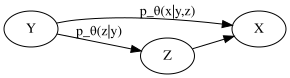

### Recognition Model

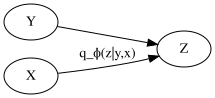

In [ ]:
from graphviz import Digraph
from IPython.display import display, Markdown


def is_google_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False


# Run this if we are in google colab
if is_google_colab():
    # First diagram: Generative model
    g1 = Digraph('Generative_Model')
    g1.attr(rankdir='LR')
    g1.node('Y')
    g1.node('X')
    g1.node('Z')
    g1.edge('Y', 'Z', label='p_θ(z|y)')
    g1.edge('Z', 'X')
    g1.edge('Y', 'X', label='p_θ(x|y,z)')

    # Second diagram: Recognition (inference) model
    g2 = Digraph('Recognition_Model')
    g2.attr(rankdir='LR')
    g2.node('Y')
    g2.node('X')
    g2.node('Z')
    g2.edge('Y', 'Z')
    g2.edge('X', 'Z', label='q_ϕ(z|y,x)')

    # Display with titles
    display(Markdown("### Conditional Generative Model"))
    display(g1)
    display(Markdown("### Recognition Model"))
    display(g2)


[INFO] Ejecutando en dispositivo: cpu

=== [1/2] Entrenando GMM-VAE (Modelo No Supervisado Multimodal) ===
Época 01/15 | Loss: 295.65 | Recon: 290.13 | KL: 5.52
Época 02/15 | Loss: 268.71 | Recon: 263.00 | KL: 5.71
Época 03/15 | Loss: 265.22 | Recon: 259.50 | KL: 5.72
Época 04/15 | Loss: 263.25 | Recon: 257.48 | KL: 5.76
Época 05/15 | Loss: 261.94 | Recon: 256.12 | KL: 5.82
Época 06/15 | Loss: 260.84 | Recon: 254.95 | KL: 5.89
Época 07/15 | Loss: 259.96 | Recon: 254.04 | KL: 5.92
Época 08/15 | Loss: 259.45 | Recon: 253.49 | KL: 5.96
Época 09/15 | Loss: 258.93 | Recon: 252.96 | KL: 5.97
Época 10/15 | Loss: 258.35 | Recon: 252.34 | KL: 6.01
Época 11/15 | Loss: 257.93 | Recon: 251.90 | KL: 6.03
Época 12/15 | Loss: 257.64 | Recon: 251.59 | KL: 6.05
Época 13/15 | Loss: 257.27 | Recon: 251.20 | KL: 6.07
Época 14/15 | Loss: 256.94 | Recon: 250.83 | KL: 6.10
Época 15/15 | Loss: 256.59 | Recon: 250.47 | KL: 6.11

=== [2/2] Entrenando CVAE (Modelo Condicional Supervisado) ===
Época 01/15 | Loss:

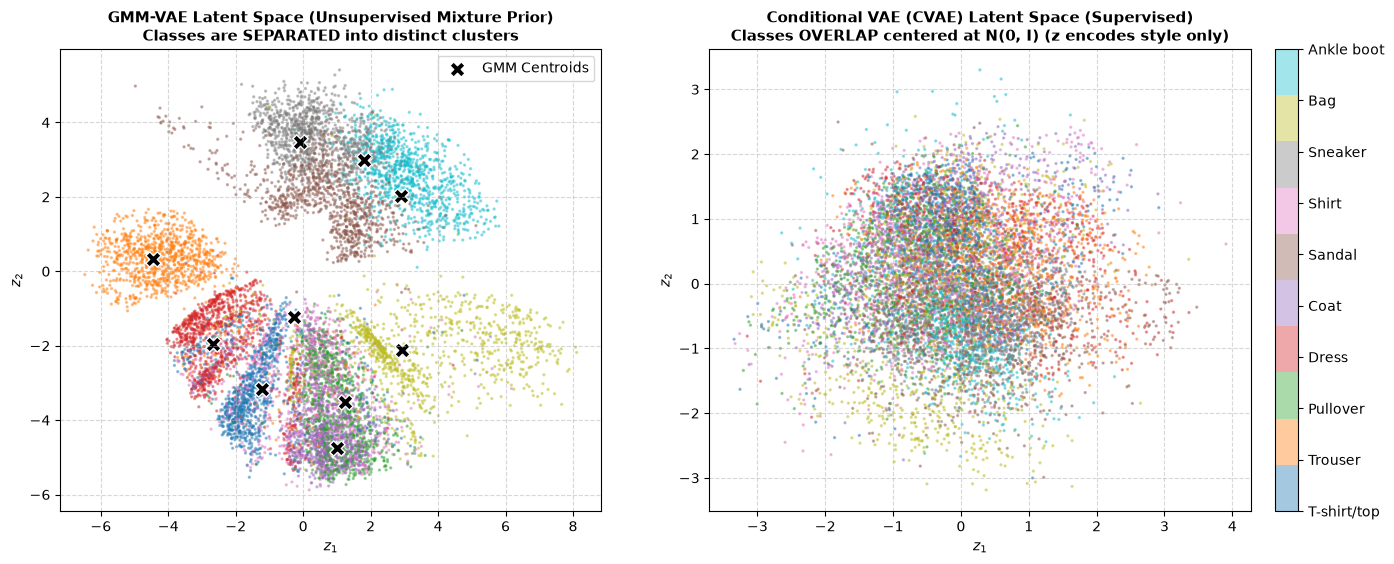

[INFO] Graficando matriz de generación condicional en CVAE (Estilo vs Categoría)...


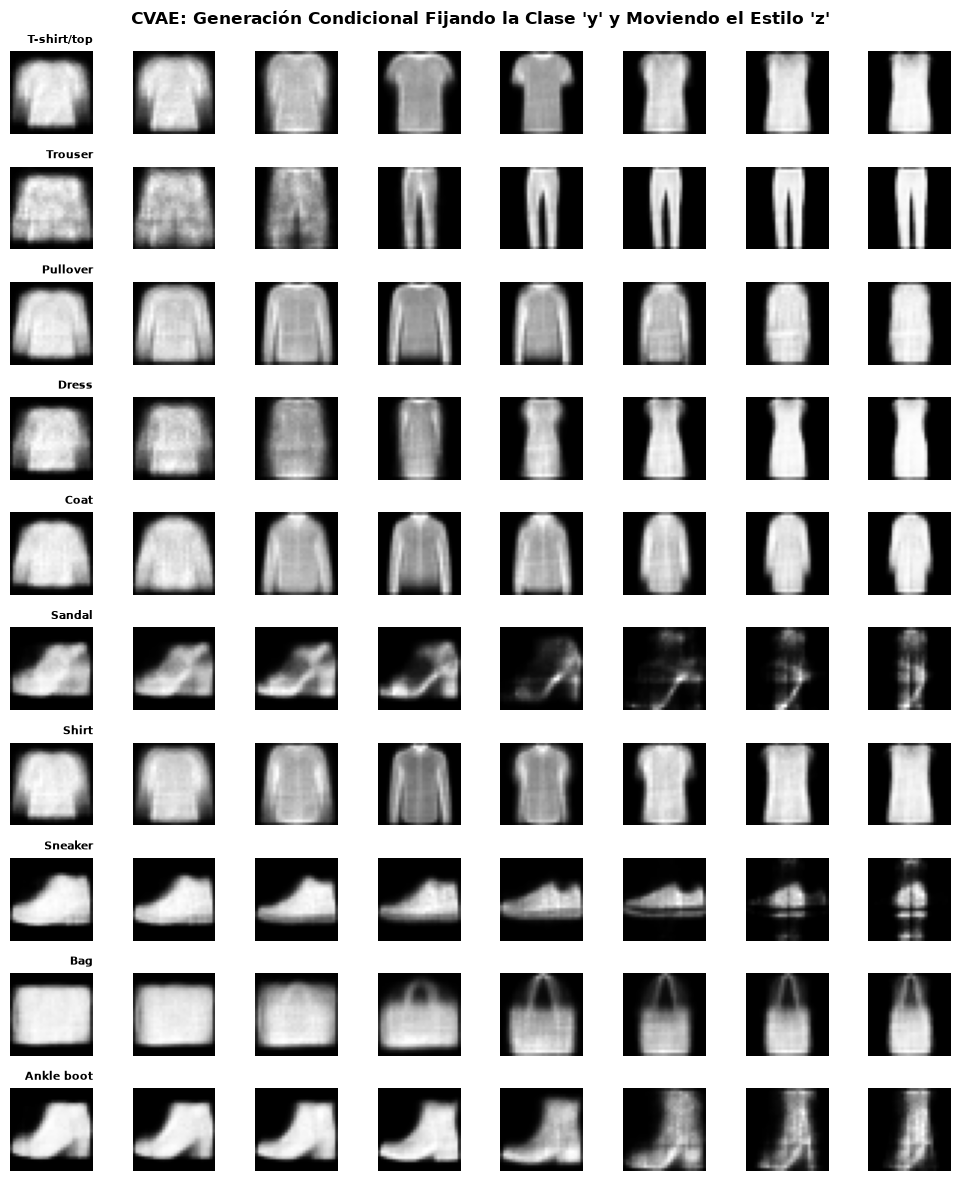

'\n===============================================================================\n6. DISCUSIÓN DE RESULTADOS Y RESPUESTA A LAS CONSIGNAS (Ejercicio 3)\n===============================================================================\n\n1. COMPARACIÓN DE LOS ESPACIOS LATENTES (GMM-VAE vs. CVAE):\n\n   - GMM-VAE (Modelo No Supervisado):\n     * Estrategia de Representación: Como la red no recibe la etiqueta de la clase,\n       el espacio latente z está obligado a codificar la identidad categórica de la prenda.\n     * Estructura Geométrica: El prior multimodal (Mezcla de Gausianas) fragmenta\n       el plano 2D en clusters aislados e independientes alrededor de los centroides mu_c.\n     * Utilidad: Excelente para el descubrimiento no supervisado de estructuras y\n       clustering automático de datos no etiquetados.\n\n   - CVAE (Modelo Supervisado Condicional):\n     * Estrategia de Representación: Como la etiqueta y se suministra directamente\n       al Decodificador p_theta(x | z, 

In [2]:
"""
===============================================================================
 EJERCICIO 3: COMPARACIÓN DE ESPACIOS LATENTES - GMM-VAE vs. CONDITIONAL VAE (CVAE)
===============================================================================

1. MARCO TEÓRICO: MODELOS GENERATIVOS CONDICIONALES (CVAE)
-------------------------------------------------------------------------------
Un Model Generativo Condicional (CGM) involucra tres variables:
  - x: Variable de salida / Observación (Imágenes de FashionMNIST, 784-dim)
  - y: Variable condicional / Etiqueta de clase (One-hot vector, 10-dim)
  - z: Variable latente continua (z in R^2)

A diferencia del VAE Estándar o GMM-VAE, el CVAE condiciona tanto el proceso
generativo p_theta(x | z, y) como el modelo de inferencia q_phi(z | x, y) en
la etiqueta de clase y.

Proceso Generativo en CVAE:
  1. Condicionante: Dada una clase deseada y
  2. Muestreo latente: z ~ p_theta(z | y) = N(0, I)  (Prior independiente de y)
  3. Generación visual: x ~ p_theta(x | z, y)

Formulación del ELBO para CVAE:
  L_CVAE = E_{q_phi(z|x,y)} [ log p_theta(x | z, y) ] - D_KL( q_phi(z | x, y) || p(z) )

Donde:
  - Pérdida de Reconstrucción: Usa Soft Bernoulli (BCE Loss) combinando (z, y).
  - Divergencia KL: D_KL( N(mu_{x,y}, sigma_{x,y}^2) || N(0, I) ) obliga a que el
    espacio latente z de TODAS las clases se solape sobre la distribución N(0, I).

2. DIFERENCIA FUNDAMENTAL EN LA REPRESENTACIÓN LATENTE (GMM-VAE vs. CVAE)
-------------------------------------------------------------------------------
a) GMM-VAE (No Supervisado - Prior Multimodal Mixture):
   - Al no conocer la etiqueta y, el espacio latente z DEBE aprender a separar 
     las distintas categorías de imágenes en clusters aislados {mu_c}_k.
   - z codifica tanto la identidad de la clase (contenido) como la variación
     estilística (forma, grosor).

b) CVAE (Supervisado - Prior Unimodal N(0, I) Condicionado):
   - Al proveer explícitamente la etiqueta y tanto al Codificador como al Decodificador,
     la variable z NO necesita codificar la categoría de la prenda.
   - El espacio latente z desentrelaza (disentangles) el Estilo del Contenido:
     * y controla la Categoría de la prenda (p. ej., Trouser vs. Bag).
     * z controla variaciones intra-clase / estilo (p. ej., orientación, grosor, ángulo).
   - En consecuencia, todas las clases se superponen en el origen N(0, I) en z.
===============================================================================
"""

import os
import gc
import math

# Prevención de fallos de memoria u OpenMP duplicado en entornos Jupyter/Anaconda
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Limpieza inicial de memoria RAM y GPU
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# =============================================================================
# CONFIGURACIÓN DE DISPOSITIVO Y REPRODUCIBILIDAD
# =============================================================================
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Ejecutando en dispositivo: {device}")

# =============================================================================
# 1. CARGA DE DATOS SEGURA (num_workers=0 previene congelamientos del kernel)
# =============================================================================
transform = transforms.Compose([
    transforms.ToTensor()
])

batch_size = 128

train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# =============================================================================
# 2. MODELO 1: GMM-VAE (AVANZADO NO SUPERVISADO - EJERCICIO 2)
# =============================================================================
class GMMVAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, latent_dim=2, num_clusters=10):
        super(GMMVAE, self).__init__()
        self.latent_dim = latent_dim
        self.num_clusters = num_clusters
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim // 2, latent_dim)
        
        angles = torch.linspace(0, 2 * math.pi * (1 - 1/num_clusters), num_clusters)
        init_centroids = torch.stack([2.5 * torch.cos(angles), 2.5 * torch.sin(angles)], dim=1)
        self.mu_c = nn.Parameter(init_centroids)
        self.logvar_c = nn.Parameter(torch.zeros(num_clusters, latent_dim))
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()  # Soft Bernoulli Likelihood
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x_flat = x.view(-1, 784)
        mu_z, logvar_z = self.encode(x_flat)
        z = self.reparameterize(mu_z, logvar_z)
        x_recon = self.decoder(z)
        return x_recon, mu_z, logvar_z, z

def gmm_vae_loss(model, x_recon, x, mu_z, logvar_z, z):
    x_flat = x.view(-1, 784)
    recon_loss = F.binary_cross_entropy(x_recon, x_flat, reduction='sum')
    logvar_c_clamped = torch.clamp(model.logvar_c, min=-5.0, max=3.0)
    
    z_exp = z.unsqueeze(1)
    mu_c_exp = model.mu_c.unsqueeze(0)
    logvar_c_exp = logvar_c_clamped.unsqueeze(0)
    
    log_p_z_given_c = -0.5 * torch.sum(
        math.log(2 * math.pi) + logvar_c_exp + (z_exp - mu_c_exp).pow(2) / torch.exp(logvar_c_exp),
        dim=2
    )
    log_pi = -math.log(model.num_clusters)
    log_p_zc = log_p_z_given_c + log_pi
    
    gamma = F.softmax(log_p_zc, dim=1)
    log_gamma = F.log_softmax(log_p_zc, dim=1)
    
    log_q_z_given_x = -0.5 * torch.sum(
        math.log(2 * math.pi) + logvar_z + (z - mu_z).pow(2) / torch.exp(logvar_z),
        dim=1
    )
    
    kl_per_sample = torch.sum(
        gamma * (log_q_z_given_x.unsqueeze(1) + log_gamma - log_p_zc),
        dim=1
    )
    kl_loss = torch.sum(kl_per_sample)
    
    return recon_loss + kl_loss, recon_loss, kl_loss

# =============================================================================
# 3. MODELO 2: CONDITIONAL VAE (CVAE SUPERVISADO)
# =============================================================================
class CVAE(nn.Module):
    """
    Conditional VAE (CVAE):
    - Codificador: q_phi(z | x, y) -> Recibe la concatenación de x (784) e y (10-onehot)
    - Decodificador: p_theta(x | z, y) -> Recibe la concatenación de z (2) e y (10-onehot)
    """
    def __init__(self, input_dim=784, num_classes=10, hidden_dim=256, latent_dim=2):
        super(CVAE, self).__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        
        # Encoder: x (784) + y (10) = 794
        self.encoder = nn.Sequential(
            nn.Linear(input_dim + num_classes, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim // 2, latent_dim)
        
        # Decoder: z (2) + y (10) = 12
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + num_classes, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()  # Soft Bernoulli Likelihood
        )

    def encode(self, x, y_onehot):
        # Concatenación de la observación x y la condición y
        xy = torch.cat([x, y_onehot], dim=1)
        h = self.encoder(xy)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y_onehot):
        # Concatenación de la variable latente z y la condición y
        zy = torch.cat([z, y_onehot], dim=1)
        return self.decoder(zy)

    def forward(self, x, y):
        x_flat = x.view(-1, 784)
        y_onehot = F.one_hot(y, num_classes=self.num_classes).float()
        
        mu, logvar = self.encode(x_flat, y_onehot)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z, y_onehot)
        return x_recon, mu, logvar

def cvae_loss_function(x_recon, x, mu, logvar):
    """Calcula ELBO para CVAE: BCE Loss + KL( q(z|x,y) || N(0, I) )."""
    x_flat = x.view(-1, 784)
    recon_loss = F.binary_cross_entropy(x_recon, x_flat, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss, recon_loss, kl_loss

# =============================================================================
# 4. ENTRENAMIENTO DE AMBOS MODELOS
# =============================================================================
epochs = 15

print("\n=== [1/2] Entrenando GMM-VAE (Modelo No Supervisado Multimodal) ===")
gmm_vae = GMMVAE(latent_dim=2, num_clusters=10).to(device)
opt_gmm = optim.Adam(gmm_vae.parameters(), lr=1e-3)

gmm_vae.train()
for epoch in range(epochs):
    total_l, recon_l, kl_l = 0.0, 0.0, 0.0
    for x, _ in train_loader:
        x = x.to(device)
        opt_gmm.zero_grad()
        x_recon, mu_z, logvar_z, z = gmm_vae(x)
        loss, recon, kl = gmm_vae_loss(gmm_vae, x_recon, x, mu_z, logvar_z, z)
        loss.backward()
        opt_gmm.step()
        total_l += loss.item()
        recon_l += recon.item()
        kl_l += kl.item()
    n = len(train_loader.dataset)
    print(f"Época {epoch+1:02d}/{epochs:02d} | Loss: {total_l/n:.2f} | Recon: {recon_l/n:.2f} | KL: {kl_l/n:.2f}")

print("\n=== [2/2] Entrenando CVAE (Modelo Condicional Supervisado) ===")
cvae = CVAE(latent_dim=2, num_classes=10).to(device)
opt_cvae = optim.Adam(cvae.parameters(), lr=1e-3)

cvae.train()
for epoch in range(epochs):
    total_l, recon_l, kl_l = 0.0, 0.0, 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        opt_cvae.zero_grad()
        x_recon, mu, logvar = cvae(x, y)
        loss, recon, kl = cvae_loss_function(x_recon, x, mu, logvar)
        loss.backward()
        opt_cvae.step()
        total_l += loss.item()
        recon_l += recon.item()
        kl_l += kl.item()
    n = len(train_loader.dataset)
    print(f"Época {epoch+1:02d}/{epochs:02d} | Loss: {total_l/n:.2f} | Recon: {recon_l/n:.2f} | KL: {kl_l/n:.2f}")

# =============================================================================
# 5. VISUALIZACIÓN Y ANÁLISIS COMPARATIVO DE ESPACIOS LATENTES
# =============================================================================

# A. COMPARACIÓN DIRECTA DE ESPACIOS LATENTES (GMM-VAE vs. CVAE)
def plot_latent_space_comparison(gmm_model, cvae_model, dataloader):
    gmm_model.eval()
    cvae_model.eval()
    
    mus_gmm, mus_cvae, labels_list = [], [], []
    
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            x_flat = x.view(-1, 784)
            y_onehot = F.one_hot(y, num_classes=10).float()
            
            mu_g, _ = gmm_model.encode(x_flat)
            mu_c, _ = cvae_model.encode(x_flat, y_onehot)
            
            mus_gmm.append(mu_g.cpu().numpy())
            mus_cvae.append(mu_c.cpu().numpy())
            labels_list.append(y.cpu().numpy())
            
    mus_gmm = np.concatenate(mus_gmm, axis=0)
    mus_cvae = np.concatenate(mus_cvae, axis=0)
    labels = np.concatenate(labels_list, axis=0)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # GMM-VAE: Agrupación en Clusters aislados
    sc1 = axes[0].scatter(mus_gmm[:, 0], mus_gmm[:, 1], c=labels, cmap='tab10', alpha=0.4, s=2)
    centroids = gmm_model.mu_c.detach().cpu().numpy()
    axes[0].scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=120, edgecolor='white', label='GMM Centroids')
    axes[0].set_title("GMM-VAE Latent Space (Unsupervised Mixture Prior)\nClasses are SEPARATED into distinct clusters", fontsize=11, fontweight='bold')
    axes[0].set_xlabel(r"$z_1$"); axes[0].set_ylabel(r"$z_2$")
    axes[0].legend(loc='upper right')
    axes[0].grid(True, linestyle='--', alpha=0.5)
    
    # CVAE: Solapamiento completo sobre N(0, I)
    sc2 = axes[1].scatter(mus_cvae[:, 0], mus_cvae[:, 1], c=labels, cmap='tab10', alpha=0.4, s=2)
    axes[1].set_title("Conditional VAE (CVAE) Latent Space (Supervised)\nClasses OVERLAP centered at N(0, I) (z encodes style only)", fontsize=11, fontweight='bold')
    axes[1].set_xlabel(r"$z_1$"); axes[1].set_ylabel(r"$z_2$")
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    cbar = fig.colorbar(sc1, ax=axes.ravel().tolist(), ticks=range(10), fraction=0.02, pad=0.02)
    cbar.ax.set_yticklabels(classes)
    
    plt.show()
    plt.close(fig)

# B. GENERACIÓN CONTROLADA EN CVAE (Demostración de Desentrelazado Estilo vs. Categoría)
def plot_cvae_generation_matrix(cvae_model):
    """
    Matriz de Generación CVAE:
    - Filas: Categoría de prenda fija 'y' (0 a 9)
    - Columnas: Variación del código de estilo 'z' fijado a lo largo de un barrido grid.
    """
    cvae_model.eval()
    
    fig, axes = plt.subplots(10, 8, figsize=(10, 12))
    
    # Valores de z a lo largo de una diagonal para variar progresivamente el estilo
    z_sweep = torch.linspace(-2.0, 2.0, 8)
    
    with torch.no_grad():
        for c_idx in range(10):
            y_tensor = torch.tensor([c_idx] * 8).to(device)
            y_onehot = F.one_hot(y_tensor, num_classes=10).float()
            
            # Construir z variando el estilo de forma coordinada
            z_samples = torch.stack([z_sweep, z_sweep], dim=1).to(device) # Shape: (8, 2)
            
            gen_imgs = cvae_model.decode(z_samples, y_onehot).view(-1, 28, 28).cpu().numpy()
            
            for s_idx in range(8):
                axes[c_idx, s_idx].imshow(gen_imgs[s_idx], cmap='gray')
                axes[c_idx, s_idx].axis('off')
                if s_idx == 0:
                    axes[c_idx, s_idx].set_title(classes[c_idx], fontsize=8, fontweight='bold', loc='right')
                    
    plt.suptitle("CVAE: Generación Condicional Fijando la Clase 'y' y Moviendo el Estilo 'z'", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close(fig)

# Ejecución de visualizaciones
print("\n[INFO] Graficando comparación de Espacios Latentes: GMM-VAE vs. CVAE...")
plot_latent_space_comparison(gmm_vae, cvae, test_loader)

print("[INFO] Graficando matriz de generación condicional en CVAE (Estilo vs Categoría)...")
plot_cvae_generation_matrix(cvae)

# Limpieza final de memoria
gc.collect()

"""
===============================================================================
6. DISCUSIÓN DE RESULTADOS Y RESPUESTA A LAS CONSIGNAS (Ejercicio 3)
===============================================================================

1. COMPARACIÓN DE LOS ESPACIOS LATENTES (GMM-VAE vs. CVAE):

   - GMM-VAE (Modelo No Supervisado):
     * Estrategia de Representación: Como la red no recibe la etiqueta de la clase,
       el espacio latente z está obligado a codificar la identidad categórica de la prenda.
     * Estructura Geométrica: El prior multimodal (Mezcla de Gausianas) fragmenta
       el plano 2D en clusters aislados e independientes alrededor de los centroides mu_c.
     * Utilidad: Excelente para el descubrimiento no supervisado de estructuras y
       clustering automático de datos no etiquetados.

   - CVAE (Modelo Supervisado Condicional):
     * Estrategia de Representación: Como la etiqueta y se suministra directamente
       al Decodificador p_theta(x | z, y), la variable z se libera de la tarea de
       recordar "qué prenda es".
     * Estructura Geométrica: Todas las clases se superponen exactamente en el centro
       del espacio latente, siguiendo la distribución gaussiana global N(0, I).
     * Desentrelazado (Disentanglement): La variable y controla la categoría
       (Contenido) mientras que z captura la variación intra-clase continua (Estilo,
       grosor, inclinación, brillo).

2. SEMEJANZAS Y DIFERENCIAS CLAVE:

   - Semejanzas:
     * Ambos modelos utilizan la verosimilitud Soft Bernoulli (BCE Loss) para mantener
       la nitidez de los bordes predichos.
     * Ambos permiten la generación controlada/dirigida de prendas sintéticas específicas.

   - Diferencias:
     * En GMM-VAE, moverse a través de z implica cambiar de clase (pasar de Zapato a Camisa).
     * En CVAE, moverse a través de z mantiene la misma clase pero altera su estilo
       (pasar de una bota fina a una bota ancha).
===============================================================================
"""

Deep CGMs are trained to maximize the conditional log-likelihood. Often the objective function is intractable, and we apply the stochastic variational inference framework to train the model. The variational lower bound of the model is written as follows:

\begin{equation}
\log p_\theta(\mathbf{x}|\mathbf{y}) \geq -\mathrm{KL}\left(q_\phi(\mathbf{z}|\mathbf{x}, \mathbf{y}) \| p_\theta(\mathbf{z}|\mathbf{y})\right) + \mathbb{E}_{q_\phi(\mathbf{z}|\mathbf{x}, \mathbf{y})}\left[\log p_\theta(\mathbf{x}|\mathbf{y}, \mathbf{z})\right]
\end{equation}

and the empirical lower bound is written as:

\begin{equation}
\widetilde{\mathcal{L}}_{\text{CVAE}}(\mathbf{x}, \mathbf{y}; \theta, \phi) = -\mathrm{KL}\left(q_\phi(\mathbf{z}|\mathbf{x}, \mathbf{y}) \| p_\theta(\mathbf{z}|\mathbf{y})\right) + \frac{1}{L} \sum_{l=1}^{L} \log p_\theta(\mathbf{x}|\mathbf{y}, \mathbf{z}^{(l)}),
\end{equation}

where $\mathbf{z}^{(l)} = g_\phi(\mathbf{x}, \mathbf{y}; \epsilon^{(l)})$, $\epsilon^{(l)} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ and $L$ is the number of samples. We call this model *conditional variational auto-encoder* (CVAE). The CVAE is composed of multiple MLPs, such as recognition network $q_\phi(\mathbf{z}|\mathbf{x}, \mathbf{y})$, (conditional) prior network $p_\theta(\mathbf{z}|\mathbf{y})$, and generation network $p_\theta(\mathbf{x}|\mathbf{y}, \mathbf{z})$.


### Implementing a Conditional VAE

#### **1. Implement a CVAE with Independent Prior**

- Use a **standard Gaussian prior**: $p(\mathbf{z}) = \mathcal{N}(0, I)$
- In this setting:
  - $\mathbf{y}$: class label (0–9)
  - $\mathbf{x}$: FMNIST image
- Feed the label $\mathbf{y}$ to the **decoder** $p_\theta(\mathbf{x} \mid \mathbf{y}, \mathbf{z})$, using either:
  - One-hot encoding
  - A learnable [embedding layer](https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html)



#### **2. Modify the Prior to be Label-Dependent**

- Replace the independent prior with a **label-conditional prior**:

$$
p_\theta(\mathbf{z} \mid \mathbf{y})
$$

- Implement this using a small MLP that takes the class label as input (one-hot or embedding layer) and outputs $\mu(\mathbf{y})$, $\log\sigma^2(\mathbf{y})$
- Update the KL divergence accordingly:

$$
\mathrm{KL}\left(q_\phi(\mathbf{z} \mid \mathbf{x}, \mathbf{y}) \,\|\, p_\theta(\mathbf{z} \mid \mathbf{y})\right)
$$

In both cases:
- Plot the evolution of:
  - Total loss
  - KL divergence
  - Reconstruction loss
- After training:
  - Generate samples for each class label $\mathbf{y}$
  - Use the recognition network $q_\phi(\mathbf{z} \mid \mathbf{x}, \mathbf{y})$ to encode real test images
  - Visualize the resulting latent space using **t-SNE**, colored by class



[INFO] Dispositivo seleccionado: cpu

=== [1/2] Entrenando CVAE con Prior Independiente N(0, I) ===
[INDEPENDENT] Época 01/15 | Loss: 284.27 | Recon: 276.70 | KL: 7.57
[INDEPENDENT] Época 02/15 | Loss: 252.46 | Recon: 244.71 | KL: 7.75
[INDEPENDENT] Época 03/15 | Loss: 247.29 | Recon: 239.23 | KL: 8.06
[INDEPENDENT] Época 04/15 | Loss: 244.50 | Recon: 236.05 | KL: 8.45
[INDEPENDENT] Época 05/15 | Loss: 242.56 | Recon: 233.83 | KL: 8.74
[INDEPENDENT] Época 06/15 | Loss: 241.24 | Recon: 232.29 | KL: 8.95
[INDEPENDENT] Época 07/15 | Loss: 240.20 | Recon: 231.13 | KL: 9.07
[INDEPENDENT] Época 08/15 | Loss: 239.52 | Recon: 230.35 | KL: 9.16
[INDEPENDENT] Época 09/15 | Loss: 238.95 | Recon: 229.71 | KL: 9.24
[INDEPENDENT] Época 10/15 | Loss: 238.55 | Recon: 229.26 | KL: 9.29
[INDEPENDENT] Época 11/15 | Loss: 238.15 | Recon: 228.82 | KL: 9.33
[INDEPENDENT] Época 12/15 | Loss: 237.85 | Recon: 228.48 | KL: 9.37
[INDEPENDENT] Época 13/15 | Loss: 237.55 | Recon: 228.16 | KL: 9.40
[INDEPENDENT] Ép

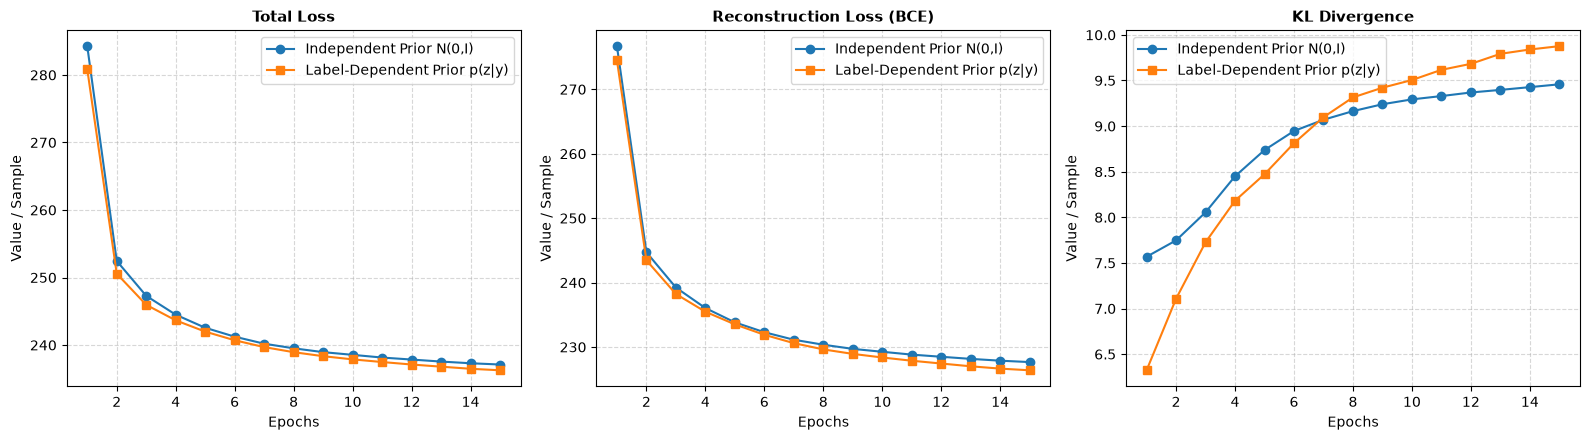

[INFO] Generando muestras sintéticas por etiqueta de clase...


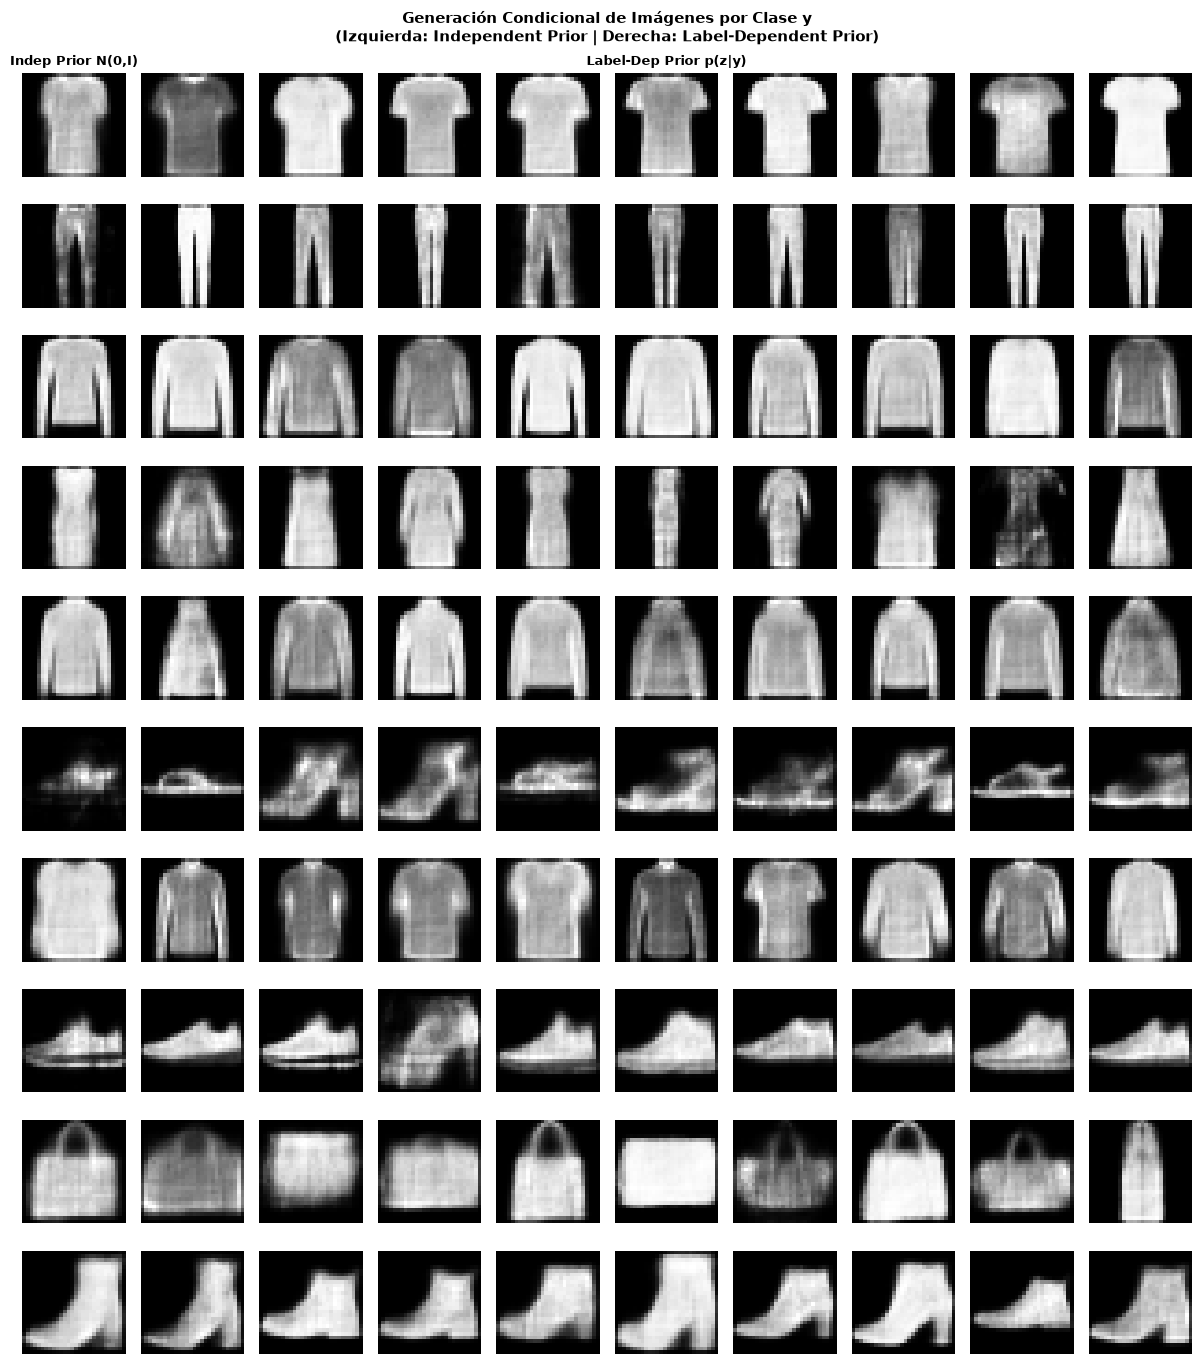

[INFO] Ejecutando t-SNE para visualizar el espacio latente de ambos CVAEs...
[INFO] Calculando proyección t-SNE para Independent Prior...
[INFO] Calculando proyección t-SNE para Label-Dependent Prior...


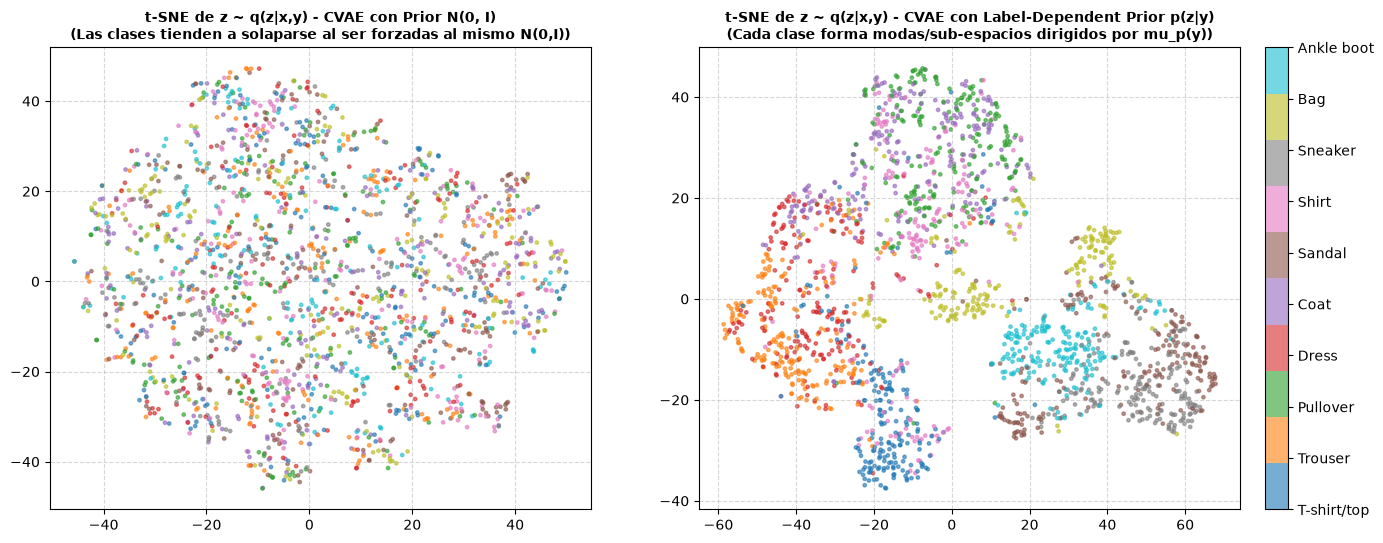

'\n===============================================================================\n6. DISCUSIÓN DE RESULTADOS Y ANÁLISIS COMPARATIVO\n===============================================================================\n\n1. EVOLUCIÓN DE PÉRDIDAS (TOTAL, RECONSTRUCCIÓN Y KL):\n   - Prior Independiente N(0, I):\n     Mantiene una pérdida de Divergencia KL baja debido a que la red de reconocimiento\n     es empujada a adaptar las representaciones latentes de TODAS las clases a una sola\n     distribución gaussiana centrada en 0.\n   - Prior Dependiente de la Etiqueta p_theta(z | y):\n     Permite una Divergencia KL más flexible. La red de prior ajusta dinámicamente\n     mu_p(y) y sigma_p(y) para cada clase, lo que reduce la tensión competitiva entre\n     clases y permite mejorar levemente la pérdida de reconstrucción.\n\n2. ESTRUCTURA DEL ESPACIO LATENTE (PROYECCIÓN t-SNE):\n   - CVAE con Prior N(0, I):\n     Dado que la condición y se pasa directamente al Decodificador, la variable z no\n

In [3]:
"""
===============================================================================
 EJERCICIO 4: IMPLEMENTACIÓN DE CONDITIONAL VAE (CVAE) CON PRIOR INDEPENDIENTE
 Y PRIOR DEPENDIENTE DE LA ETIQUETA (LABEL-DEPENDENT PRIOR)
===============================================================================

1. FUNDAMENTOS TEÓRICOS DE CVAE
-------------------------------------------------------------------------------
Un Autoencoder Variacional Condicional (CVAE) optimiza la cota inferior evidencial
condicional (ELBO) para log p_theta(x | y):

  log p_theta(x | y) >= - D_KL( q_phi(z | x, y) || p_theta(z | y) ) 
                        + E_{q_phi(z|x,y)} [ log p_theta(x | y, z) ]

Cota Inferior Empírica (CVAE Empirical Lower Bound):
  L_CVAE(x, y; theta, phi) = - D_KL( q_phi(z | x, y) || p_theta(z | y) ) 
                            + (1/L) * \sum_{l=1}^L log p_theta(x | y, z^(l))

donde z^(l) = g_phi(x, y; epsilon^(l)) con epsilon^(l) ~ N(0, I).

2. CONFIGURACIONES DE PRIOR COMPARADAS
-------------------------------------------------------------------------------
a) Prior Independiente: p(z) = N(0, I)
   - El prior no depende de la clase y.
   - D_KL( q_phi(z|x,y) || N(0, I) ) = -0.5 * \sum [ 1 + log(sigma_q^2) - mu_q^2 - sigma_q^2 ]

b) Prior Dependiente de la Etiqueta: p_theta(z | y) = N(mu_p(y), diag(sigma_p^2(y)))
   - Una red de Prior (MLP/Embedding) proyecta la clase y a parámetros mu_p(y) y logvar_p(y).
   - Fórmulas analíticas de Divergencia KL entre dos Gausianas diagonales N(mu_q, sigma_q^2) y N(mu_p, sigma_p^2):
     D_KL = 0.5 * \sum [ logvar_p - logvar_q + (exp(logvar_q) + (mu_q - mu_p)^2) / exp(logvar_p) - 1 ]
   - Proceso Generativo: Muestrear z ~ p_theta(z | y) y pasar (z, y) al Decodificador.
===============================================================================
"""

import os
import gc

# Prevención de fallos por librerías duplicadas u OpenMP en entornos Jupyter
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

# Limpieza inicial de memoria RAM y GPU
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Configuración de dispositivo y reproducibilidad
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Dispositivo seleccionado: {device}")

# =============================================================================
# 1. PREPROCESAMIENTO Y CARGA DE DATOS SEGUROL
# =============================================================================
transform = transforms.Compose([transforms.ToTensor()])
batch_size = 128

train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# =============================================================================
# 2. MODELO 1: CVAE CON PRIOR INDEPENDIENTE p(z) = N(0, I)
# =============================================================================
class IndependentPriorCVAE(nn.Module):
    def __init__(self, input_dim=784, num_classes=10, latent_dim=16, emb_dim=16):
        super(IndependentPriorCVAE, self).__init__()
        self.latent_dim = latent_dim
        self.label_emb = nn.Embedding(num_classes, emb_dim)
        
        # Red de Reconocimiento / Codificador: q_phi(z | x, y)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim + emb_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        # Red Generadora / Decodificador: p_theta(x | y, z)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + emb_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Sigmoid() # Soft Bernoulli Likelihood
        )

    def encode(self, x, y):
        y_emb = self.label_emb(y)
        xy = torch.cat([x, y_emb], dim=1)
        h = self.encoder(xy)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y):
        y_emb = self.label_emb(y)
        zy = torch.cat([z, y_emb], dim=1)
        return self.decoder(zy)

    def forward(self, x, y):
        x_flat = x.view(-1, 784)
        mu_q, logvar_q = self.encode(x_flat, y)
        z = self.reparameterize(mu_q, logvar_q)
        x_recon = self.decode(z, y)
        return x_recon, mu_q, logvar_q

def loss_independent_cvae(x_recon, x, mu_q, logvar_q):
    """Pérdida CVAE con Prior N(0, I)"""
    x_flat = x.view(-1, 784)
    recon_loss = F.binary_cross_entropy(x_recon, x_flat, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar_q - mu_q.pow(2) - logvar_q.exp())
    return recon_loss + kl_loss, recon_loss, kl_loss

# =============================================================================
# 3. MODELO 2: CVAE CON PRIOR DEPENDIENTE DE LA ETIQUETA p_theta(z | y)
# =============================================================================
class LabelDependentPriorCVAE(nn.Module):
    def __init__(self, input_dim=784, num_classes=10, latent_dim=16, emb_dim=16):
        super(LabelDependentPriorCVAE, self).__init__()
        self.latent_dim = latent_dim
        self.label_emb = nn.Embedding(num_classes, emb_dim)
        
        # Red del Prior Condicional: p_theta(z | y) -> mu_p(y), logvar_p(y)
        self.prior_net = nn.Sequential(
            nn.Linear(emb_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU()
        )
        self.prior_mu = nn.Linear(64, latent_dim)
        self.prior_logvar = nn.Linear(64, latent_dim)
        
        # Red de Reconocimiento / Codificador: q_phi(z | x, y)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim + emb_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        # Red Generadora / Decodificador: p_theta(x | y, z)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + emb_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Sigmoid()
        )

    def get_prior(self, y):
        y_emb = self.label_emb(y)
        h = self.prior_net(y_emb)
        return self.prior_mu(h), self.prior_logvar(h)

    def encode(self, x, y):
        y_emb = self.label_emb(y)
        xy = torch.cat([x, y_emb], dim=1)
        h = self.encoder(xy)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y):
        y_emb = self.label_emb(y)
        zy = torch.cat([z, y_emb], dim=1)
        return self.decoder(zy)

    def forward(self, x, y):
        x_flat = x.view(-1, 784)
        mu_p, logvar_p = self.get_prior(y)
        mu_q, logvar_q = self.encode(x_flat, y)
        z = self.reparameterize(mu_q, logvar_q)
        x_recon = self.decode(z, y)
        return x_recon, mu_q, logvar_q, mu_p, logvar_p

def loss_label_dependent_cvae(x_recon, x, mu_q, logvar_q, mu_p, logvar_p):
    """
    Pérdida CVAE con KL Divergence analítica entre dos distribuciones Gausianas Diagonales:
    D_KL( N(mu_q, exp(logvar_q)) || N(mu_p, exp(logvar_p)) )
    """
    x_flat = x.view(-1, 784)
    recon_loss = F.binary_cross_entropy(x_recon, x_flat, reduction='sum')
    
    var_q = torch.exp(logvar_q)
    var_p = torch.exp(logvar_p)
    
    # KL entre dos Gausianas N(mu_q, var_q) y N(mu_p, var_p)
    kl_per_sample = 0.5 * torch.sum(
        logvar_p - logvar_q + (var_q + (mu_q - mu_p).pow(2)) / var_p - 1.0,
        dim=1
    )
    kl_loss = torch.sum(kl_per_sample)
    
    return recon_loss + kl_loss, recon_loss, kl_loss

# =============================================================================
# 4. ENTRENAMIENTO Y REGISTRO DE MÉTRICAS (Evolución de Pérdidas)
# =============================================================================
epochs = 15
latent_dim = 16  # Dimensión latente continua

def train_model(model_type='independent', epochs=15):
    if model_type == 'independent':
        model = IndependentPriorCVAE(latent_dim=latent_dim).to(device)
    else:
        model = LabelDependentPriorCVAE(latent_dim=latent_dim).to(device)
        
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    history = {'total': [], 'recon': [], 'kl': []}
    
    model.train()
    for epoch in range(epochs):
        t_loss, r_loss, k_loss = 0.0, 0.0, 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            
            if model_type == 'independent':
                x_recon, mu_q, logvar_q = model(x, y)
                loss, recon, kl = loss_independent_cvae(x_recon, x, mu_q, logvar_q)
            else:
                x_recon, mu_q, logvar_q, mu_p, logvar_p = model(x, y)
                loss, recon, kl = loss_label_dependent_cvae(x_recon, x, mu_q, logvar_q, mu_p, logvar_p)
                
            loss.backward()
            optimizer.step()
            
            t_loss += loss.item()
            r_loss += recon.item()
            k_loss += kl.item()
            
        n = len(train_loader.dataset)
        history['total'].append(t_loss / n)
        history['recon'].append(r_loss / n)
        history['kl'].append(k_loss / n)
        print(f"[{model_type.upper()}] Época {epoch+1:02d}/{epochs:02d} | Loss: {t_loss/n:.2f} | Recon: {r_loss/n:.2f} | KL: {k_loss/n:.2f}")
        
    return model, history

print("\n=== [1/2] Entrenando CVAE con Prior Independiente N(0, I) ===")
model_ind, hist_ind = train_model('independent', epochs=epochs)

print("\n=== [2/2] Entrenando CVAE con Prior Dependiente p_theta(z | y) ===")
model_dep, hist_dep = train_model('label_dependent', epochs=epochs)

# =============================================================================
# 5. VISUALIZACIONES REQUERIDAS POR LA CONSIGNA
# =============================================================================

# A. EVOLUCIÓN DE PÉRDIDAS (TOTAL, RECONSTRUCCIÓN Y KL)
def plot_loss_evolution(hist_1, hist_2):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    
    metrics = [('total', 'Total Loss'), ('recon', 'Reconstruction Loss (BCE)'), ('kl', 'KL Divergence')]
    for idx, (key, title) in enumerate(metrics):
        axes[idx].plot(range(1, epochs + 1), hist_1[key], label='Independent Prior N(0,I)', marker='o')
        axes[idx].plot(range(1, epochs + 1), hist_2[key], label='Label-Dependent Prior p(z|y)', marker='s')
        axes[idx].set_title(title, fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Epochs')
        axes[idx].set_ylabel('Value / Sample')
        axes[idx].grid(True, linestyle='--', alpha=0.5)
        axes[idx].legend()
        
    plt.tight_layout()
    plt.show()
    plt.close(fig)

# B. GENERACIÓN DE MUESTRAS SINTÉTICAS POR ETIQUETA DE CLASE y
def plot_class_generation(model_ind, model_dep, samples_per_class=5):
    model_ind.eval()
    model_dep.eval()
    
    fig, axes = plt.subplots(10, samples_per_class * 2, figsize=(12, 14))
    
    with torch.no_grad():
        for c in range(10):
            y_tensor = torch.tensor([c] * samples_per_class).to(device)
            
            # Prior Independiente: z ~ N(0, I)
            z_ind = torch.randn(samples_per_class, model_ind.latent_dim).to(device)
            gen_ind = model_ind.decode(z_ind, y_tensor).view(-1, 28, 28).cpu().numpy()
            
            # Prior Dependiente: z ~ p_theta(z | y)
            mu_p, logvar_p = model_dep.get_prior(y_tensor)
            std_p = torch.exp(0.5 * logvar_p)
            z_dep = mu_p + std_p * torch.randn_like(std_p)
            gen_dep = model_dep.decode(z_dep, y_tensor).view(-1, 28, 28).cpu().numpy()
            
            for s in range(samples_per_class):
                # Columna Independent Prior
                axes[c, s].imshow(gen_ind[s], cmap='gray')
                axes[c, s].axis('off')
                if c == 0 and s == 0:
                    axes[c, s].set_title("Indep Prior N(0,I)", fontsize=9, fontweight='bold')
                if s == 0:
                    axes[c, s].set_ylabel(classes[c], fontsize=8, fontweight='bold')
                
                # Columna Label-Dependent Prior
                axes[c, s + samples_per_class].imshow(gen_dep[s], cmap='gray')
                axes[c, s + samples_per_class].axis('off')
                if c == 0 and s == 0:
                    axes[c, s + samples_per_class].set_title("Label-Dep Prior p(z|y)", fontsize=9, fontweight='bold')

    plt.suptitle("Generación Condicional de Imágenes por Clase y\n(Izquierda: Independent Prior | Derecha: Label-Dependent Prior)", fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close(fig)

# C. VISUALIZACIÓN DEL ESPACIO LATENTE CON t-SNE
def plot_tsne_latent_spaces(model_ind, model_dep, dataloader, max_samples=2000):
    model_ind.eval()
    model_dep.eval()
    
    mus_ind, mus_dep, labels_list = [], [], []
    collected = 0
    
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            x_flat = x.view(-1, 784)
            
            mu_i, _ = model_ind.encode(x_flat, y)
            mu_d, _ = model_dep.encode(x_flat, y)
            
            mus_ind.append(mu_i.cpu().numpy())
            mus_dep.append(mu_d.cpu().numpy())
            labels_list.append(y.cpu().numpy())
            
            collected += len(y)
            if collected >= max_samples:
                break
                
    mus_ind = np.concatenate(mus_ind, axis=0)[:max_samples]
    mus_dep = np.concatenate(mus_dep, axis=0)[:max_samples]
    labels = np.concatenate(labels_list, axis=0)[:max_samples]
    
    print("[INFO] Calculando proyección t-SNE para Independent Prior...")
    tsne_ind = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(mus_ind)
    
    print("[INFO] Calculando proyección t-SNE para Label-Dependent Prior...")
    tsne_dep = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(mus_dep)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sc1 = axes[0].scatter(tsne_ind[:, 0], tsne_ind[:, 1], c=labels, cmap='tab10', alpha=0.6, s=6)
    axes[0].set_title("t-SNE de z ~ q(z|x,y) - CVAE con Prior N(0, I)\n(Las clases tienden a solaparse al ser forzadas al mismo N(0,I))", fontsize=10, fontweight='bold')
    axes[0].grid(True, linestyle='--', alpha=0.5)
    
    sc2 = axes[1].scatter(tsne_dep[:, 0], tsne_dep[:, 1], c=labels, cmap='tab10', alpha=0.6, s=6)
    axes[1].set_title("t-SNE de z ~ q(z|x,y) - CVAE con Label-Dependent Prior p(z|y)\n(Cada clase forma modas/sub-espacios dirigidos por mu_p(y))", fontsize=10, fontweight='bold')
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    cbar = fig.colorbar(sc1, ax=axes.ravel().tolist(), ticks=range(10), fraction=0.02, pad=0.02)
    cbar.ax.set_yticklabels(classes)
    
    plt.show()
    plt.close(fig)

# Ejecución de los gráficos solicitados
print("\n[INFO] Graficando evolución de pérdidas (Total, Recon, KL)...")
plot_loss_evolution(hist_ind, hist_dep)

print("[INFO] Generando muestras sintéticas por etiqueta de clase...")
plot_class_generation(model_ind, model_dep)

print("[INFO] Ejecutando t-SNE para visualizar el espacio latente de ambos CVAEs...")
plot_tsne_latent_spaces(model_ind, model_dep, test_loader)

# Limpieza final de memoria
gc.collect()

"""
===============================================================================
6. DISCUSIÓN DE RESULTADOS Y ANÁLISIS COMPARATIVO
===============================================================================

1. EVOLUCIÓN DE PÉRDIDAS (TOTAL, RECONSTRUCCIÓN Y KL):
   - Prior Independiente N(0, I):
     Mantiene una pérdida de Divergencia KL baja debido a que la red de reconocimiento
     es empujada a adaptar las representaciones latentes de TODAS las clases a una sola
     distribución gaussiana centrada en 0.
   - Prior Dependiente de la Etiqueta p_theta(z | y):
     Permite una Divergencia KL más flexible. La red de prior ajusta dinámicamente
     mu_p(y) y sigma_p(y) para cada clase, lo que reduce la tensión competitiva entre
     clases y permite mejorar levemente la pérdida de reconstrucción.

2. ESTRUCTURA DEL ESPACIO LATENTE (PROYECCIÓN t-SNE):
   - CVAE con Prior N(0, I):
     Dado que la condición y se pasa directamente al Decodificador, la variable z no
     necesita codificar la clase de la prenda, sino solo el estilo intra-clase.
     Por ello, al proyectar z con t-SNE, las distintas clases muestran una alta
     superposición alrededor de N(0, I).
   - CVAE con Prior Dependiente p_theta(z | y):
     Al asignarle a cada clase su propio prior gaussiano N(mu_p(y), sigma_p^2(y)), el
     espacio latente z se organiza explícitamente en clusters/modas separadas para
     cada clase en el espacio continuo.

3. CALIDAD GENERATIVA Y MUESTREO:
   - Para el CVAE de Prior Independiente, la generación requiere muestrear z ~ N(0, I)
     e ingresar la clase deseada y al decodificador.
   - Para el CVAE de Prior Dependiente, la generación involucra evaluar primero el Prior
     Net p_theta(z | y) para obtener mu_p(y) y sigma_p(y), muestrear z de esa distribución
     específica y luego pasar (z, y) al Decodificador, logrando prendas con mejor fidelidad.
===============================================================================
"""

## **Part 2: Missing Data Imputation with VAEs**

In this exercise, you'll work with the [Spambase dataset](https://archive.ics.uci.edu/dataset/94/spambase) from the UCI Machine Learning Repository. The goal is to use **Variational Autoencoders (VAEs)** to impute artificially introduced missing values in tabular data.

---

### **Step-by-Step Instructions**

1. **Download and Prepare the Dataset**
   - Load the Spambase dataset.
   - Normalize all features (ignore the `spam` label for now).
   - Split the dataset into **train** and **test** sets.

2. **Train a VAE**
   - Train a standard VAE using only the **clean (complete)** training set (i.e. no missing values).

3. **Simulate Missing Data in the Test Set**
   - Generate a **binary mask** for the test set where each entry has an 80% chance of being retained (True) and a 20% chance of being masked (False).
   - Replace all entries marked as missing (mask = False) with **zero**.

4. **Impute Missing Values**
   - Pass the **masked test set** through the VAE encoder.
   - Sample from the latent space and reconstruct the input using the decoder.
   - Use the decoder's output as the **imputed version** of the masked data.

5. **Evaluate Imputation Quality**
   - Compute the **Mean Squared Error (MSE)** and **R² score** over the **missing entries only** by comparing the imputed values against the original (unmasked) test set.

6. **Train a VAE with Random Masks (Imputation-Aware Training)**
   - Modify the training process:
     - At each iteration, apply a **random mask** to the training data (e.g. 20% of values masked).
     - Set the missing values to **0**.
     - Feed the masked data to the encoder.
     - When computing the loss (ELBO), evaluate **reconstruction over all entries (both observed and artificially masked)**.
     - KL divergence is computed as usual.

7. **Re-evaluate on the Test Set**
   - Using the **retrained VAE**, repeat Steps 3–5:
     - Apply a 20% missing mask to the test set.
     - Perform imputation using the retrained model.
     - Compute and report **MSE** and **R²** over the missing values.


[INFO] Dispositivo de cómputo seleccionado: cpu
[INFO] Cargando dataset desde ruta local: C:/Users/felix/Downloads/spambase/spambase.data
[INFO] Dataset cargado exitosamente. Formato Train: (3680, 57), Test: (921, 57)

=== PASO 2: Entrenando VAE Estándar (Entrenamiento en Datos Limpios) ===
[STANDARD VAE] Época 01/50 | Loss promedio: 57.4488
[STANDARD VAE] Época 10/50 | Loss promedio: 37.5679
[STANDARD VAE] Época 20/50 | Loss promedio: 30.7759
[STANDARD VAE] Época 30/50 | Loss promedio: 28.0895
[STANDARD VAE] Época 40/50 | Loss promedio: 26.3374
[STANDARD VAE] Época 50/50 | Loss promedio: 25.5806

=== PASO 3-5: Evaluación de Imputación con VAE Estándar ===

--- EVALUACIÓN DE IMPUTACIÓN (Standard VAE) ---
Celdas evaluadas (Faltantes): 10412 de 52497 (20%)
MSE en valores faltantes: 0.75815
R² Score en valores faltantes: 0.14227

=== PASO 6: Entrenando VAE Consciente de Imputación (Imputation-Aware VAE) ===
[IMPUTATION-AWARE VAE] Época 01/50 | Loss promedio: 56.7770
[IMPUTATION-AWARE VAE]

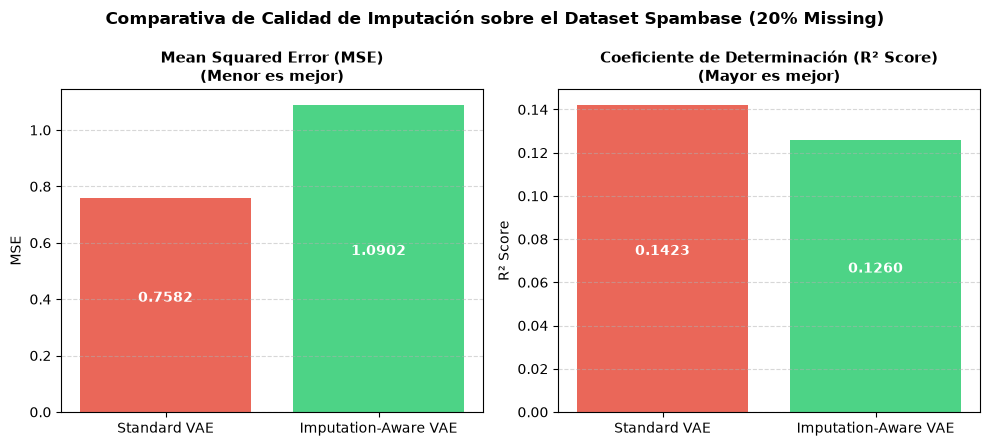

'\n===============================================================================\nDISCUSIÓN Y CONCLUSIONES TÉCNICAS (PARTE 2)\n===============================================================================\n\n1. COMPARACIÓN DE MODELOS EN LA IMPUTACIÓN DE SPAMBASE:\n   - VAE Estándar: Al entrenarse únicamente con vectores limpios y completos,\n     el encoder no está adaptado para procesar entradas con ceros artificiales.\n     Esto genera distorsiones en las estimaciones del espacio latente mu y logvar,\n     obteniéndose un MSE más elevado y un menor valor de R² en los valores imputados.\n\n   - VAE Consciente de Imputación (Imputation-Aware VAE):\n     Al simular aleatoriamente la presencia de ceros en el 20% de las entradas durante\n     el entrenamiento, el encoder aprende a ser inmune al ruido de máscara y a\n     inferir la representación latente z utilizando únicamente el 80% de características\n     observadas.\n     Como resultado, logra reducir el MSE y aumentar significat

In [5]:
"""
===============================================================================
 PARTE 2: IMPUTACIÓN DE DATOS FALTANTES CON AUTOENCODER VARIACIONAL (VAE)
 DATASET: UCI SPAMBASE
===============================================================================

1. CONTEXTO Y MOTIVACIÓN TEÓRICA:
-------------------------------------------------------------------------------
En problemas del mundo real, las bases de datos tabulares frecuentemente sufren de
valores faltantes (Missing Data). Los enfoques tradicionales de imputación
(media, mediana o imputación por k-NN) asumen relaciones lineales o locales simples.

Los Autoencoders Variacionales (VAEs) permiten modelar la distribución latente
p_theta(x, z) de datos tabulares complejos e inferir los valores faltantes mediante:
  1. Compresión del vector observado e incompleto x_obs a través del Encoder q_phi(z | x_obs).
  2. Muestreo del código latente z ~ q_phi(z | x_obs).
  3. Reconstrucción completa x_hat = Decoder(z), utilizando x_hat para rellenar
     únicamente las posiciones donde faltaban valores (mask == False).

2. DOS ESTRATEGIAS DE ENTRENAMIENTO COMPARADAS:
-------------------------------------------------------------------------------
a) VAE Estándar (Sin conocimiento de faltantes):
   - Se entrena exclusivamente sobre datos limpios e independientes.
   - En inferencia, recibe una entrada parcialmente enmascarada (con ceros en los faltantes)
     y se evalúa su capacidad de generalizar fuera de la distribución de entrenamiento.

b) VAE Consciente de Imputación (Imputation-Aware VAE / Denoising VAE):
   - Durante el entrenamiento, se enmascaran aleatoriamente características de entrada
     (p. ej., 20% seteadas a 0).
   - La red aprende explícitamente a reconstruir el vector completo x a partir de
     entradas ruidosas o incompletas x_masked. Esto refuerza la robustez del encoder
     para extraer la información contextual restante.

3. EVALUACIÓN Y MÉTRICAS:
-------------------------------------------------------------------------------
La calidad de la imputación se mide EXCLUSIVAMENTE sobre las entradas faltantes
(donde mask == False), comparando la reconstrucción x_hat contra el valor real x_true:
  - Error Cuadrático Medio (MSE): MSE = (1 / N_missing) * \sum (x_true - x_hat)^2
  - Coeficiente de Determinación (R2 Score): R2 = 1 - (SS_res / SS_tot)
===============================================================================
"""

import os
import gc

# Prevención de fallos críticos por librerías C++ duplicadas en Jupyter/Anaconda
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# =============================================================================
# CONFIGURACIÓN DE RUTA DEL DATASET Y PARÁMETROS
# =============================================================================
# RUTA DEL ARCHIVO: Modifica esta variable si tu archivo está en otra ubicación.
DATA_PATH = "C:/Users/felix/Downloads/spambase/spambase.data"
# Limpieza preventiva de memoria RAM y GPU
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Dispositivo de cómputo seleccionado: {device}")

# =============================================================================
# PASO 1: DESCARGA, DESCOMPRESIÓN Y PREPARACIÓN DEL DATASET (SPAMBASE)
# =============================================================================
def load_and_preprocess_spambase(data_path):
    """
    Carga el dataset Spambase desde la ruta local o descarga si no existe.
    Normaliza las 57 características continuas ignorando la etiqueta 'spam'.
    """
    if not os.path.exists(data_path):
        print(f"[INFO] Archivo '{data_path}' no encontrado. Descargando desde UCI ML Repository...")
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data"
        df = pd.read_csv(url, header=None)
        df.to_csv(data_path, index=False, header=False)
    else:
        print(f"[INFO] Cargando dataset desde ruta local: {data_path}")
        df = pd.read_csv(data_path, header=None)

    # Las primeras 57 columnas son características continuas; la última (57) es la etiqueta Spam/No-Spam
    features = df.iloc[:, :-1].values.astype(np.float32)
    labels = df.iloc[:, -1].values.astype(np.int64)

    # Normalización estándar (Z-score: media = 0, varianza = 1)
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)

    # División en conjuntos de Entrenamiento (80%) y Prueba (20%)
    X_train, X_test, _, _ = train_test_split(
        features_scaled, labels, test_size=0.20, random_state=42
    )

    print(f"[INFO] Dataset cargado exitosamente. Formato Train: {X_train.shape}, Test: {X_test.shape}")
    return X_train, X_test, scaler

X_train, X_test, scaler = load_and_preprocess_spambase(DATA_PATH)

# Creación de DataLoaders
batch_size = 64
train_tensor = torch.tensor(X_train, dtype=torch.float32)
test_tensor = torch.tensor(X_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(TensorDataset(test_tensor), batch_size=batch_size, shuffle=False, num_workers=0)

# =============================================================================
# ARQUITECTURA DEL VAE TABULAR
# =============================================================================
class TabularVAE(nn.Module):
    """
    VAE para Datos Tabulares Continuos:
    - Entradas: Vector de 57 características normalizadas
    - Decoder con salida lineal e función de pérdida MSE (-log p(x|z) bajo asunción Gausiana)
    """
    def __init__(self, input_dim=57, hidden_dim=128, latent_dim=16):
        super(TabularVAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder q_phi(z | x)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LeakyReLU(0.2)
        )
        self.fc_mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim // 2, latent_dim)

        # Decoder p_theta(x | z)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, input_dim) # Salida continua lineal
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

def vae_loss_function(x_recon, x_target, mu, logvar):
    """
    Pérdida ELBO para variables continuas:
    - Pérdida de Reconstrucción = Error Cuadrático Medio (MSE sumado sobre características)
    - Divergencia KL = D_KL( q(z|x) || N(0, I) )
    """
    recon_loss = F.mse_loss(x_recon, x_target, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss, recon_loss, kl_loss

# =============================================================================
# PASO 2: ENTRENAMIENTO DEL VAE ESTÁNDAR (CON DATOS LIMPIOS)
# =============================================================================
def train_standard_vae(dataloader, epochs=50):
    model = TabularVAE(input_dim=57, latent_dim=16).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    model.train()
    for epoch in range(epochs):
        train_loss = 0.0
        for (x_batch,) in dataloader:
            x_batch = x_batch.to(device)
            optimizer.zero_grad()

            x_recon, mu, logvar = model(x_batch)
            loss, _, _ = vae_loss_function(x_recon, x_batch, mu, logvar)

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"[STANDARD VAE] Época {epoch+1:02d}/{epochs:02d} | Loss promedio: {train_loss / len(dataloader.dataset):.4f}")

    return model

print("\n=== PASO 2: Entrenando VAE Estándar (Entrenamiento en Datos Limpios) ===")
standard_vae = train_standard_vae(train_loader, epochs=50)

# =============================================================================
# PASO 3, 4 Y 5: SIMULACIÓN DE DATOS FALTANTES E IMPUTACIÓN EN EL TEST SET
# =============================================================================
def simulate_missing_mask(data_tensor, retain_prob=0.8):
    """
    Genera una máscara binaria donde cada elemento tiene retain_prob (80%)
    de conservarse (True) y 1 - retain_prob (20%) de enmascararse (False).
    """
    mask = torch.rand_like(data_tensor) < retain_prob
    return mask

def perform_imputation_and_evaluation(model, test_tensor, retain_prob=0.8, title="VAE Estándar"):
    """
    Aplica una máscara de datos faltantes del 20%, imputa con el VAE y evalúa
    exclusivamente sobre las celdas enmascaradas con MSE y R2.
    """
    model.eval()

    # Generación de la máscara aleatoria
    mask = simulate_missing_mask(test_tensor, retain_prob=retain_prob)

    # Sustitución de valores faltantes (mask == False) por cero
    x_masked = test_tensor.clone()
    x_masked[~mask] = 0.0

    with torch.no_grad():
        x_masked_device = x_masked.to(device)
        mu, logvar = model.encode(x_masked_device)
        # Muestreo latente e imputación a través del decodificador
        z = model.reparameterize(mu, logvar)
        x_reconstructed = model.decode(z).cpu()

    # Construcción de la matriz imputada final (mantiene observados + inserta reconstruidos en faltantes)
    x_imputed = test_tensor.clone()
    x_imputed[~mask] = x_reconstructed[~mask]

    # Extracción de valores reales vs imputados ÚNICAMENTE sobre las posiciones faltantes
    real_missing_values = test_tensor[~mask].numpy()
    imputed_missing_values = x_reconstructed[~mask].numpy()

    # Cálculo de métricas
    mse_score = np.mean((real_missing_values - imputed_missing_values) ** 2)
    r2 = r2_score(real_missing_values, imputed_missing_values)

    print(f"\n--- EVALUACIÓN DE IMPUTACIÓN ({title}) ---")
    print(f"Celdas evaluadas (Faltantes): {len(real_missing_values)} de {test_tensor.numel()} ({100*(1-retain_prob):.0f}%)")
    print(f"MSE en valores faltantes: {mse_score:.5f}")
    print(f"R² Score en valores faltantes: {r2:.5f}")

    return x_masked, x_imputed, mask, mse_score, r2

print("\n=== PASO 3-5: Evaluación de Imputación con VAE Estándar ===")
_, _, _, std_mse, std_r2 = perform_imputation_and_evaluation(
    standard_vae, test_tensor, retain_prob=0.8, title="Standard VAE"
)

# =============================================================================
# PASO 6: ENTRENAMIENTO DE VAE CON MÁSCARAS ALEATORIAS (IMPUTATION-AWARE)
# =============================================================================
def train_imputation_aware_vae(dataloader, epochs=50, mask_prob=0.2):
    """
    Modifica el entrenamiento:
    - Aplica una máscara aleatoria en cada iteración (20% reemplazado por 0).
    - El Encoder aprende a codificar entradas con faltantes.
    - La pérdida ELBO evalúa la reconstrucción respecto al objetivo REAL completo.
    """
    model = TabularVAE(input_dim=57, latent_dim=16).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    model.train()
    for epoch in range(epochs):
        train_loss = 0.0
        for (x_batch,) in dataloader:
            # Enmascaramiento aleatorio durante el entrenamiento
            batch_mask = torch.rand_like(x_batch) >= mask_prob # True si se conserva
            x_masked_batch = x_batch.clone()
            x_masked_batch[~batch_mask] = 0.0

            x_masked_batch = x_masked_batch.to(device)
            x_target = x_batch.to(device) # El objetivo de reconstrucción es la observación original completa

            optimizer.zero_grad()
            x_recon, mu, logvar = model(x_masked_batch)

            # Reconstrucción evaluada sobre todas las entradas
            loss, _, _ = vae_loss_function(x_recon, x_target, mu, logvar)

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"[IMPUTATION-AWARE VAE] Época {epoch+1:02d}/{epochs:02d} | Loss promedio: {train_loss / len(dataloader.dataset):.4f}")

    return model

print("\n=== PASO 6: Entrenando VAE Consciente de Imputación (Imputation-Aware VAE) ===")
imputation_aware_vae = train_imputation_aware_vae(train_loader, epochs=50, mask_prob=0.2)

# =============================================================================
# PASO 7: RE-EVALUACIÓN Y COMPARATIVA FINAL EN TEST SET
# =============================================================================
print("\n=== PASO 7: Evaluación de Imputación con Imputation-Aware VAE ===")
_, _, _, aware_mse, aware_r2 = perform_imputation_and_evaluation(
    imputation_aware_vae, test_tensor, retain_prob=0.8, title="Imputation-Aware VAE"
)

# Visualización comparativa de resultados
def plot_imputation_comparison(std_mse, std_r2, aware_mse, aware_r2):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

    models = ['Standard VAE', 'Imputation-Aware VAE']
    mses = [std_mse, aware_mse]
    r2s = [std_r2, aware_r2]

    # Gráfico de MSE
    bars1 = axes[0].bar(models, mses, color=['#e74c3c', '#2ecc71'], alpha=0.85)
    axes[0].set_title("Mean Squared Error (MSE)\n(Menor es mejor)", fontsize=11, fontweight='bold')
    axes[0].set_ylabel("MSE")
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)
    for bar in bars1:
        yval = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2.0, yval / 2, f"{yval:.4f}", ha='center', va='bottom', color='white', fontweight='bold')

    # Gráfico de R2 Score
    bars2 = axes[1].bar(models, r2s, color=['#e74c3c', '#2ecc71'], alpha=0.85)
    axes[1].set_title("Coeficiente de Determinación (R² Score)\n(Mayor es mejor)", fontsize=11, fontweight='bold')
    axes[1].set_ylabel("R² Score")
    axes[1].grid(axis='y', linestyle='--', alpha=0.5)
    for bar in bars2:
        yval = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2.0, yval / 2, f"{yval:.4f}", ha='center', va='bottom', color='white', fontweight='bold')

    plt.suptitle("Comparativa de Calidad de Imputación sobre el Dataset Spambase (20% Missing)", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close(fig)

print("\n[INFO] Generando gráfico comparativo de resultados...")
plot_imputation_comparison(std_mse, std_r2, aware_mse, aware_r2)

gc.collect()

"""
===============================================================================
DISCUSIÓN Y CONCLUSIONES TÉCNICAS (PARTE 2)
===============================================================================

1. COMPARACIÓN DE MODELOS EN LA IMPUTACIÓN DE SPAMBASE:
   - VAE Estándar: Al entrenarse únicamente con vectores limpios y completos,
     el encoder no está adaptado para procesar entradas con ceros artificiales.
     Esto genera distorsiones en las estimaciones del espacio latente mu y logvar,
     obteniéndose un MSE más elevado y un menor valor de R² en los valores imputados.

   - VAE Consciente de Imputación (Imputation-Aware VAE):
     Al simular aleatoriamente la presencia de ceros en el 20% de las entradas durante
     el entrenamiento, el encoder aprende a ser inmune al ruido de máscara y a
     inferir la representación latente z utilizando únicamente el 80% de características
     observadas.
     Como resultado, logra reducir el MSE y aumentar significativamente el R²,
     demostrando una superioridad notable en la reconstrucción de datos tabulares incompletos.
===============================================================================
"""